## 1. Individual Maps

### 1.1 Cambridge

In [6]:
import pandas as pd
import numpy as np
import geopandas as gpd
import folium
from pathlib import Path
from IPython.display import display, clear_output
import ipywidgets as widgets

ROOT_DIR = Path.cwd()
if not (ROOT_DIR / 'Cambridge').exists():
    ROOT_DIR = ROOT_DIR.parent
if not (ROOT_DIR / 'Cambridge').exists():
    raise FileNotFoundError('Could not locate repo root containing Cambridge/, Boston/, and Somerville/.')

# Crime data
# https://data.cambridgema.gov/Public-Safety/Crime-Reports/xuad-73uj/about_data
neighborhoods_crime_cambridge = pd.read_csv(ROOT_DIR / 'Cambridge' / 'Crime_Reports_20250112.csv')
neighborhoods_crime_cambridge = neighborhoods_crime_cambridge[['Crime Date Time', 'Crime', 'Neighborhood', 'Reporting Area']].copy()
neighborhoods_crime_cambridge['Date'] = pd.to_datetime(neighborhoods_crime_cambridge['Crime Date Time'].str.split(' ').str[0])

# Population data from 2020 Census
# https://www.cambridgema.gov/-/media/Files/policedepartment/AnnualCrimeReports/2023AnnualCrimeReport_FINAL2.pdf
neighborhoods_pop_2020_cambridge = {
    "East Cambridge": 13246, "MIT": 6238, "Inman/Harrington": 6718,
    "Area 4": 7280, "Cambridgeport": 13083, "Mid-Cambridge": 13974,
    "Riverside": 12114, "Agassiz": 5146, "Peabody": 12471,
    "West Cambridge": 8450, "North Cambridge": 15372, "Highlands": 1646,
    "Strawberry Hill": 2665
}

# Geographical data
# https://www.cambridgema.gov/GIS/gisdatadictionary/Boundary/BOUNDARY_CDDNeighborhoods
shapefile_path_cambridge = ROOT_DIR / 'Cambridge' / 'BOUNDARY_CDDNeighborhoods.shp' / 'BOUNDARY_CDDNeighborhoods.shp'
geo_df_cambridge = gpd.read_file(shapefile_path_cambridge)
if geo_df_cambridge.crs != "EPSG:4326":
    geo_df_cambridge = geo_df_cambridge.to_crs(epsg=4326)

# Crime categories mapping
crime_macro_categories_cambridge = {
    # Violent Crimes
    'Aggravated Assault': 'Violent Crime', 'Homicide': 'Violent Crime',
    'Kidnapping': 'Violent Crime', 'Simple Assault': 'Violent Crime',
    'Stalking': 'Violent Crime', 'Street Robbery': 'Violent Crime',
    'Threats': 'Violent Crime', 'Weapon Violations': 'Violent Crime',

    # Property Crimes
    'Arson': 'Property Crime', 'Auto Theft': 'Property Crime',
    'Commercial Break': 'Property Crime', 'Commercial Robbery': 'Property Crime',
    'Housebreak': 'Property Crime', 'Larceny (Misc)': 'Property Crime',
    'Larceny from Building': 'Property Crime', 'Larceny from MV': 'Property Crime',
    'Larceny from Person': 'Property Crime', 'Larceny from Residence': 'Property Crime',
    'Larceny of Bicycle': 'Property Crime', 'Larceny of Plate': 'Property Crime',
    'Larceny of Services': 'Property Crime', 'Mal. Dest. Property': 'Property Crime',
    'Shoplifting': 'Property Crime',

    # Drug Offenses
    'Drugs': 'Drug Offense',

    # White-Collar Crimes
    'Counterfeiting': 'White-Collar Crime', 'Embezzlement': 'White-Collar Crime',
    'Extortion/Blackmail': 'White-Collar Crime', 'Forgery': 'White-Collar Crime',
    'Flim Flam': 'White-Collar Crime',

    # Public Order Crimes
    'Annoying & Accosting': 'Public Order Crime', 'Disorderly': 'Public Order Crime',
    'Drinking in Public': 'Public Order Crime', 'Gambling': 'Public Order Crime',
    'Noise Complaint': 'Public Order Crime', 'Peeping & Spying': 'Public Order Crime',
    'Prostitution': 'Public Order Crime', 'Rec. Stol. Property': 'Public Order Crime',
    'Trespassing': 'Public Order Crime',

    # Traffic Violations
    'Accident': 'Traffic Violation', 'Hit and Run': 'Traffic Violation',
    'Taxi Violation': 'Traffic Violation', 'OUI': 'Traffic Violation',

    # Personal Crimes
    'Domestic Dispute': 'Personal Crime', 'Harassment': 'Personal Crime',
    'Indecent Exposure': 'Personal Crime', 'Phone Calls': 'Personal Crime',
    'Sex Offender Violation': 'Personal Crime',

    # Protective Order Violations
    'Violation of H.O.': 'Protective Order Violation',
    'Violation of R.O.': 'Protective Order Violation',

    # Miscellaneous or Administrative
    'Admin Error': 'Administrative Issue',
    'Liquor Possession/Sale': 'Administrative Issue',
    'Missing Person': 'Miscellaneous',
    'Suspicious Package': 'Miscellaneous',
    'Warrant Arrest': 'Miscellaneous'
}

# Mapping dictionary for neighborhood names (for Geospatial df)
name_mapping_cambridge = {
    "The Port": "Area 4",
    "Neighborhood Nine": "Peabody",
    "Wellington-Harrington": "Inman/Harrington",
    "Mid-Cambridge": "Mid-Cambridge",
    "North Cambridge": "North Cambridge",
    "Cambridge Highlands": "Highlands",
    "Strawberry Hill": "Strawberry Hill",
    "West Cambridge": "West Cambridge",
    "Riverside": "Riverside",
    "Cambridgeport": "Cambridgeport",
    "Area 2/MIT": "MIT",
    "East Cambridge": "East Cambridge",
    "Baldwin": "Agassiz",
}

In [7]:
# Add macro crime categories
neighborhoods_crime_cambridge['Macro Crime'] = neighborhoods_crime_cambridge['Crime'].map(crime_macro_categories_cambridge)

# Map neighborhood names
geo_df_cambridge['Mapped_Name'] = geo_df_cambridge['NAME'].map(name_mapping_cambridge)

In [8]:
# Create widgets for interactive map
crime_dropdown = widgets.Dropdown(
    options=sorted(neighborhoods_crime_cambridge['Macro Crime'].unique()),
    value='Violent Crime',
    description='Crime:',
    style={'description_width': 'initial'}
)

start_date_picker = widgets.DatePicker(
    description='Start Date:',
    value=pd.to_datetime('2015-01-01'),
    style={'description_width': 'initial'}
)

end_date_picker = widgets.DatePicker(
    description='End Date:',
    value=pd.to_datetime('2025-01-07'),
    style={'description_width': 'initial'}
)

controls = widgets.HBox([crime_dropdown, start_date_picker, end_date_picker])

def render_map(selected_macro=None, start_date=None, end_date=None):
    clear_output(wait=True)
    
    # Filter data by date
    filtered_crime = neighborhoods_crime_cambridge[
        (neighborhoods_crime_cambridge['Date'] >= pd.to_datetime(start_date)) & 
        (neighborhoods_crime_cambridge['Date'] <= pd.to_datetime(end_date))
    ].copy()
    
    # Calculate crime rates
    crime_table_macro = filtered_crime.groupby(['Neighborhood', 'Macro Crime']).size().unstack('Macro Crime').fillna(0)
    rel_crime_table_macro = crime_table_macro.div(pd.Series(neighborhoods_pop_2020_cambridge), axis=0)
    
    # Create population DataFrame
    pop_df = pd.DataFrame.from_dict(neighborhoods_pop_2020_cambridge, orient='index', columns=['Population'])
    pop_df.index.name = 'Neighborhood'
    pop_df = pop_df.reset_index()

    # Merge data
    geo_df_selected = geo_df_cambridge.merge(
        rel_crime_table_macro[[selected_macro]], how='left', left_on='Mapped_Name', right_index=True
    )
    geo_df_selected = geo_df_selected.merge(
        pop_df, how='left', left_on='Mapped_Name', right_on='Neighborhood'
    )
    geo_df_selected[selected_macro] = geo_df_selected[selected_macro].round(5)

    # Create map
    geo_json = geo_df_selected.to_json()
    center_coords = geo_df_cambridge.geometry.centroid.y.mean(), geo_df_cambridge.geometry.centroid.x.mean()
    m = folium.Map(location=center_coords, zoom_start=13)

    # Add choropleth layer
    folium.Choropleth(
        geo_data=geo_json,
        data=geo_df_selected,
        columns=['Mapped_Name', selected_macro],
        key_on='feature.properties.Mapped_Name',
        fill_color='YlOrRd',
        fill_opacity=0.65,
        line_opacity=0.4,
        legend_name=f'Relative {selected_macro} Rate',
    ).add_to(m)

    # Add tooltip layer
    folium.GeoJson(
        geo_json,
        style_function=lambda x: {'fillColor': 'transparent', 'color': 'transparent'},
        tooltip=folium.GeoJsonTooltip(
            fields=['Mapped_Name', selected_macro, 'Population'],
            aliases=['Neighborhood:', f'{selected_macro} Score:', 'Population (2020):'],
            style=("background-color: white; color: #333333; font-family: arial; font-size: 12px; padding: 10px;")
        )
    ).add_to(m)
    
    display(controls)
    display(m)

def update_map(change=None):
    render_map(
        selected_macro=crime_dropdown.value,
        start_date=start_date_picker.value,
        end_date=end_date_picker.value
    )

# Link widgets to update function
crime_dropdown.observe(lambda change: update_map(change), names='value')
start_date_picker.observe(lambda change: update_map(change), names='value')
end_date_picker.observe(lambda change: update_map(change), names='value')

# Initial rendering
update_map()

C:\Users\ncomati\AppData\Local\Temp\ipykernel_35732\1931989285.py:52: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  center_coords = geo_df_cambridge.geometry.centroid.y.mean(), geo_df_cambridge.geometry.centroid.x.mean()


### 1.2 Boston

In [10]:
if 'ROOT_DIR' not in globals():
    from pathlib import Path
    ROOT_DIR = Path.cwd()
    if not (ROOT_DIR / 'Boston').exists():
        ROOT_DIR = ROOT_DIR.parent

# 
neighborhoods_crime_boston = pd.read_csv(ROOT_DIR / 'Boston' / 'Boston_Incidents_View_3136327856209597499.csv')
neighborhoods_crime_boston = neighborhoods_crime_boston[['From Date', 'Crime', 'Neighborhood', 'BPD District']].copy()
neighborhoods_crime_boston['Date'] = pd.to_datetime(neighborhoods_crime_boston['From Date'].str.split(' ').str[0])
neighborhoods_crime_boston['Crime'] = neighborhoods_crime_boston['Crime'].str.title()

neighborhoods_pop_2019_boston = pd.read_excel(ROOT_DIR / 'Boston' / '2015-2019_neighborhood_tables_2021.12.21.xlsm', header=2)
neighborhoods_pop_2019_boston.set_index('Unnamed: 0', inplace=True)
neighborhoods_pop_2019_boston = neighborhoods_pop_2019_boston.loc['Allston':'West Roxbury', 'Total Population'].to_dict()
neighborhoods_pop_2019_boston = {k.strip(): v for k, v in neighborhoods_pop_2019_boston.items()}

shapefile_path_boston = ROOT_DIR / 'Boston' / 'Boston_Neighborhood_Boundaries_Approximated_by_2020_Census_Block_Groups.shp'
geo_df_boston = gpd.read_file(shapefile_path_boston)
if geo_df_boston.crs != "EPSG:4326":
    geo_df_boston = geo_df_boston.to_crs(epsg=4326)

crime_macro_categories_boston = {
    # Violent Crimes
    'Aggravated Assault': 'Violent Crime',
    'Homicide': 'Violent Crime',
    'Simple Assault': 'Violent Crime',
    'Indecent Assault': 'Violent Crime',
    'Robbery': 'Violent Crime',
    'Rape & Attempted': 'Violent Crime',
    'Threats To Do Bodily Harm': 'Violent Crime',
    'Murder, Non-Negligent Manslaughter': 'Violent Crime',
    'Assault - Simple': 'Violent Crime',
    'Assault - Aggravated': 'Violent Crime',
    'Sex Offense - Rape - Forcible': 'Violent Crime',
    'Sex Offense - Rape - Sodomy': 'Violent Crime',
    'Fondling - Indecent Assault': 'Violent Crime',
    'Human Trafficking': 'Violent Crime',
    'Manslaughter': 'Violent Crime',
    'Offenses Against Child / Family': 'Violent Crime',
    'Weapon Violation - Carry/ Possessing/ Sale/ Traffi': 'Violent Crime',

    # Property Crimes
    'Arson': 'Property Crime',
    'Auto Theft': 'Property Crime',
    'Auto Theft - Leased/Rented Vehicle': 'Property Crime',
    'Auto Theft - Motorcycle / Scooter': 'Property Crime',
    'Auto Theft Recovery': 'Property Crime',
    'Residential Burglary': 'Property Crime',
    'Commercial Burglary': 'Property Crime',
    'Burglary - Commerical': 'Property Crime',
    'Larceny From Mv': 'Property Crime',
    'Larceny Theft From Building': 'Property Crime',
    'Other Larceny': 'Property Crime',
    'Larceny Theft Of Bicycle': 'Property Crime',
    'Larceny Shoplifting': 'Property Crime',
    'Larceny Theft From Mv - Non-Accessory': 'Property Crime',
    'Larceny All Others': 'Property Crime',
    'Recovered Stolen Property': 'Property Crime',
    'Property Found': 'Property Crime',
    'Property Lost': 'Property Crime',
    'Vandalism': 'Property Crime',
    'Larceny Purse Snatch - No Force': 'Property Crime',
    'Breaking And Entering (B&E) Motor Vehicle (No Prop': 'Property Crime',
    'Recovered - Mv Recovered In Boston (Stolen In Bost': 'Property Crime',
    'Larceny Theft Of Mv Parts & Accessories': 'Property Crime',
    'Stolen Property - Buying / Receiving / Possessing': 'Property Crime',
    'Possession Of Burglarious Tools': 'Property Crime',
    'Property - Accidental Damage': 'Property Crime',
    'Property Related Damage': 'Property Crime',
    'Property - Found': 'Property Crime',
    'Property - Lost Then Located': 'Property Crime',
    'Property - Lost/ Missing': 'Property Crime',
    'License Plate Related Incidents': 'Property Crime',

    # Drug Offenses
    'Drug Violation': 'Drug Offense',
    'Drugs - Possession/ Sale/ Manufacturing/ Use': 'Drug Offense',
    'Drugs - Possession Of Drug Paraphanalia': 'Drug Offense',
    'Sick Assist - Drug Related Illness': 'Drug Offense',

    # White-Collar Crimes
    'Fraud': 'White-Collar Crime',
    'Counterfeiting': 'White-Collar Crime',
    'Embezzlement': 'White-Collar Crime',
    'Confidence Games': 'White-Collar Crime',
    'Forgery / Counterfeiting': 'White-Collar Crime',
    'Fraud - Credit Card / Atm Fraud': 'White-Collar Crime',
    'Fraud - False Pretense / Scheme': 'White-Collar Crime',
    'Fraud - Wire': 'White-Collar Crime',
    'Fraud - Welfare': 'White-Collar Crime',
    'Identity Fraud C266.37E': 'White-Collar Crime',

    # Public Order Crimes
    'Disorderly Conduct': 'Public Order Crime',
    'Prostitution': 'Public Order Crime',
    'Trespassing': 'Public Order Crime',
    'Liquor Violation': 'Public Order Crime',
    'Noise Complaint': 'Public Order Crime',
    'Bomb Hoax': 'Public Order Crime',
    'Bomb Threat': 'Public Order Crime',
    'Gambling': 'Public Order Crime',
    'Dangerous Or Hazardous Condition': 'Public Order Crime',
    'Assembly Or Gathering Violations': 'Public Order Crime',
    'Disturbing The Peace/ Disorderly Conduct/ Gatherin': 'Public Order Crime',
    'Explosives': 'Public Order Crime',
    'Liquor Law Violation': 'Public Order Crime',
    'Noisy Party/Radio-No Arrest': 'Public Order Crime',
    'Violation - City Ordinance': 'Public Order Crime',

    # Traffic Violations
    'Mv Crash Response': 'Traffic Violation',
    'Operating Under The Influence': 'Traffic Violation',
    'M/V Accident - Personal Injury': 'Traffic Violation',
    'M/V Accident - Property Damage': 'Traffic Violation',
    'M/V Accident - Involving Pedestrian - Injury': 'Traffic Violation',
    'M/V Accident - Other': 'Traffic Violation',
    'M/V - Leaving Scene - Property Damage': 'Traffic Violation',
    'M/V - Leaving Scene - Personal Injury': 'Traffic Violation',
    'M/V Accident - Involving Pedestrian - No Injury': 'Traffic Violation',
    'M/V Accident - Other City Vehicle': 'Traffic Violation',
    'M/V Accident - Police Vehicle': 'Traffic Violation',
    'M/V Plates - Lost': 'Traffic Violation',
    'Towed Motor Vehicle': 'Traffic Violation',
    'M/V Accident - Involving Bicycle - Injury': 'Traffic Violation',
    'M/V Accident - Involving Bicycle - No Injury': 'Traffic Violation',
    'Towed': 'Traffic Violation',
    'Val - Operating After Rev/Susp.': 'Traffic Violation',
    'Val - Operating W/O Authorization Lawful': 'Traffic Violation',
    'Val - Violation Of Auto Law': 'Traffic Violation',
    'Operating Under The Influence (Oui) Alcohol': 'Traffic Violation',

    # Personal Crimes
    'Verbal Disputes': 'Personal Crime',
    'Verbal Dispute': 'Personal Crime',
    'Criminal Harassment': 'Personal Crime',
    'Harassment/ Criminal Harassment': 'Personal Crime',
    'Sex Offender Registration': 'Personal Crime',
    'Indecent Exposure/ Lewd And Lascivious/ Open And G': 'Personal Crime',
    'Child Endangerment': 'Personal Crime',
    'Failure To Register As A Sex Offender': 'Personal Crime',
    'Phone Call Complaints': 'Personal Crime',
    'Obscene Materials - Pornography': 'Personal Crime',
    'Sex Offense - Other': 'Personal Crime',
    'Sexual Assault Investigation': 'Personal Crime',
    'Sexual Assault Kit Collected': 'Personal Crime',

    # Protective Order Violations
    'Restraining Order Violations': 'Protective Order Violation',
    'Viol. Of Restraining Order W Arrest': 'Protective Order Violation',
    'Violation - Restraining Order (No Arrest)': 'Protective Order Violation',
    'Violation - Harassment Prevention Order': 'Protective Order Violation',

    # Miscellaneous or Administrative
    'Investigate Person': 'Miscellaneous',
    'Investigate Property': 'Miscellaneous',
    'Service': 'Miscellaneous',
    'Search Warrants': 'Miscellaneous',
    'Search Warrant': 'Miscellaneous',
    'Missing Person Reported': 'Miscellaneous',
    'Missing Person Located': 'Miscellaneous',
    'Missing Person - Located': 'Miscellaneous',
    'Missing Person - Not Reported - Located': 'Miscellaneous',
    'Fire Related Reports': 'Miscellaneous',
    'Fire Report': 'Miscellaneous',
    'Fire Report/Alarm - False': 'Miscellaneous',
    'Landlord/Tenant Disputes': 'Miscellaneous',
    'Landlord - Tenant': 'Miscellaneous',
    'Animal Incidents (Dog Bites, Lost Dog, Etc)': 'Miscellaneous',
    'Animal Abuse': 'Miscellaneous',
    'Death Investigation': 'Miscellaneous',
    'Prisoner Related Incidents': 'Miscellaneous',
    'Recovered - Mv Recovered In Boston (Stolen Outside': 'Miscellaneous',
    'Aircraft': 'Miscellaneous',
    'Evading Fare': 'Miscellaneous',
    'Biological Threat': 'Miscellaneous',
    'Sudden Death': 'Miscellaneous',
    'Fugitive From Justice': 'Miscellaneous',
    'Other': 'Miscellaneous',
    'Other Offense': 'Miscellaneous',
    'Ballistics': 'Miscellaneous',
    'Ballistics Evidence/Found': 'Miscellaneous',
    'Firearm Discovery': 'Miscellaneous',
    'Firearm Violations': 'Miscellaneous',
    'Firearm/Weapon - Found Or Confiscated': 'Miscellaneous',
    'Harbor Incident / Violation': 'Miscellaneous',
    'Harbor Related Incidents': 'Miscellaneous',
    'License Premise Violation': 'Miscellaneous',
    'License Violation': 'Miscellaneous',
    'Medical Assistance': 'Miscellaneous',
    'Missing Person': 'Miscellaneous',
    'Police Service Incidents': 'Miscellaneous',
    'Service To Other Agency': 'Miscellaneous',
    'Sick Assist': 'Miscellaneous',
    'Sick/Injured/Medical - Person': 'Miscellaneous',
    'Sick/Injured/Medical - Police': 'Miscellaneous',
    'Truancy / Runaway': 'Miscellaneous',
    'Violations': 'Miscellaneous',
    'Warrant Arrest - Boston Warrant (Must Be Supplemen': 'Miscellaneous',
    'Warrant Arrest - Outside Of Boston Warrant': 'Miscellaneous',
    'Warrant Arrests': 'Miscellaneous',
}

# Mapping dictionary for reassignment
name_mapping_boston = {
    "Chinatown": "Downtown",
    "Leather District": "Downtown",
    "Bay Village": "South End"
}

In [11]:
neighborhoods_crime_boston['Macro Crime'] = neighborhoods_crime_boston['Crime'].map(crime_macro_categories_boston)

# Map neighborhood names in crime data
neighborhoods_crime_boston['Mapped_Neighborhood'] = neighborhoods_crime_boston['Neighborhood'].map(name_mapping_boston).fillna(neighborhoods_crime_boston['Neighborhood'])

# Map neighborhood names in geospatial data
geo_df_boston['Mapped_Name'] = geo_df_boston['blockgr202'].map(name_mapping_boston).fillna(geo_df_boston['blockgr202'])

In [12]:
crime_dropdown_boston = widgets.Dropdown(
    options=sorted(neighborhoods_crime_boston['Macro Crime'].unique()),
    value='Violent Crime',
    description='Crime:',
    style={'description_width': 'initial'}
)

start_date_picker_boston = widgets.DatePicker(
    description='Start Date:',
    value=pd.to_datetime('2015-01-01'),
    style={'description_width': 'initial'}
)

end_date_picker_boston = widgets.DatePicker(
    description='End Date:',
    value=pd.to_datetime('2025-01-07'),
    style={'description_width': 'initial'}
)

controls_boston = widgets.HBox([crime_dropdown_boston, start_date_picker_boston, end_date_picker_boston])

def render_map_boston(selected_macro=None, start_date=None, end_date=None):
    clear_output(wait=True)

    # Filter data by date
    filtered_crime = neighborhoods_crime_boston[
        (neighborhoods_crime_boston['Date'] >= pd.to_datetime(start_date)) & 
        (neighborhoods_crime_boston['Date'] <= pd.to_datetime(end_date))
    ].copy()

    # Calculate crime rates
    crime_table_macro = filtered_crime.groupby(['Neighborhood', 'Macro Crime']).size().unstack('Macro Crime').fillna(0)
    rel_crime_table_macro = crime_table_macro.div(pd.Series(neighborhoods_pop_2019_boston), axis=0)

    # Create population DataFrame
    pop_df = pd.DataFrame.from_dict(neighborhoods_pop_2019_boston, orient='index', columns=['Population'])
    pop_df.index.name = 'Neighborhood'
    pop_df = pop_df.reset_index()

    # Merge data
    geo_df_selected = geo_df_boston.merge(
        rel_crime_table_macro[[selected_macro]], how='left', left_on='Mapped_Name', right_index=True
    )

    geo_df_selected = geo_df_selected.merge(
        pop_df, how='left', left_on='Mapped_Name', right_on='Neighborhood'
    )

    geo_df_selected[selected_macro] = geo_df_selected[selected_macro].round(5)

    # Create map
    geo_json = geo_df_selected.to_json()
    center_coords = geo_df_boston.geometry.centroid.y.mean(), geo_df_boston.geometry.centroid.x.mean()
    m = folium.Map(location=center_coords, zoom_start=12)
    
    # Add choropleth layer
    folium.Choropleth(
        geo_data=geo_json,
        data=geo_df_selected,
        columns=['Mapped_Name', selected_macro],
        key_on='feature.properties.Mapped_Name',
        fill_color='YlOrRd',
        fill_opacity=0.65,
        line_opacity=0.4,
        legend_name=f'Relative {selected_macro} Rate',
    ).add_to(m)

    # Add tooltip layer
    folium.GeoJson(
        geo_json,
        style_function=lambda x: {'fillColor': 'transparent', 'color': 'transparent'},
        tooltip=folium.GeoJsonTooltip(
            fields=['Mapped_Name', selected_macro, 'Population'],
            aliases=['Neighborhood:', f'{selected_macro} Score:', 'Population (2019):'],
            style=("background-color: white; color: #333333; font-family: arial; font-size: 12px; padding: 10px;")
        )
    ).add_to(m)

    display(controls_boston)
    display(m)

def update_map_boston(change=None):
    render_map_boston(
        selected_macro=crime_dropdown_boston.value,
        start_date=start_date_picker_boston.value,
        end_date=end_date_picker_boston.value
    )

# Link widgets to update function
crime_dropdown_boston.observe(lambda change: update_map_boston(change), names='value')
start_date_picker_boston.observe(lambda change: update_map_boston(change), names='value')
end_date_picker_boston.observe(lambda change: update_map_boston(change), names='value')

# Initial rendering
update_map_boston()

C:\Users\ncomati\AppData\Local\Temp\ipykernel_35732\1843000641.py:53: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  center_coords = geo_df_boston.geometry.centroid.y.mean(), geo_df_boston.geometry.centroid.x.mean()


### 1.3 Somerville

In [13]:
if 'ROOT_DIR' not in globals():
    from pathlib import Path
    ROOT_DIR = Path.cwd()
    if not (ROOT_DIR / 'Somerville').exists():
        ROOT_DIR = ROOT_DIR.parent

# SOMERVILLE - Crime data
# https://data.somervillema.gov/Public-Safety/Police-Data-Crime-Reports/aghs-hqvg/about_data
neighborhoods_crime_somerville = pd.read_csv(ROOT_DIR / 'Somerville' / 'Police_Data__Crime_Reports_20250114.csv')
neighborhoods_crime_somerville['Date'] = neighborhoods_crime_somerville['Day and Month Reported'].str.strip() + '/' + neighborhoods_crime_somerville['Year Reported'].astype(str)
neighborhoods_crime_somerville['Date'] = neighborhoods_crime_somerville['Date'].fillna(value=('01/01/' + neighborhoods_crime_somerville['Year Reported'].astype(str)))
neighborhoods_crime_somerville['Date'] = pd.to_datetime(neighborhoods_crime_somerville['Date'])
neighborhoods_crime_somerville = neighborhoods_crime_somerville[['Date', 'Offense Type', 'Block Code']].copy()
neighborhoods_crime_somerville['Offense Type'] = neighborhoods_crime_somerville['Offense Type'].str.title()
neighborhoods_crime_somerville

# SOMERVILLE - Population data from 2022 Census
# https://datausa.io/profile/geo/somerville-ma/
neighborhoods_pop_2022_somerville = {
    "Somerville": 80464
}

# SOMERVILLE - Geographical data
# https://data.somervillema.gov/GIS-Data/Neighborhoods/n5md-vqta/about_data
shapefile_path_somerville = ROOT_DIR / 'Somerville' / 'Neighborhoods.shp'
geo_df_somerville = gpd.read_file(shapefile_path_somerville)
if geo_df_somerville.crs != "EPSG:4326":
    geo_df_somerville = geo_df_somerville.to_crs(epsg=4326)

# MASSACHUSETTS - Load the census blocks shapefile
# https://www.mass.gov/info-details/massgis-data-2020-us-census?utm_source=chatgpt.com
census_blocks = gpd.read_file(ROOT_DIR / 'MA Census Data' / 'CENSUS2020BLOCKS_POLY.shp')

somerville_blocks = census_blocks[(census_blocks['TOWN'] == 'SOMERVILLE')]
if somerville_blocks.crs != "EPSG:4326":
    somerville_blocks = somerville_blocks.to_crs(epsg=4326)

# Ensure 'Block Code' in crime data matches 'GEOID20' format
neighborhoods_crime_somerville['Block Code'] = neighborhoods_crime_somerville['Block Code'].astype(str).str.rstrip('.0')

# Merge crime data with Somerville blocks
neighborhoods_crime_somerville = neighborhoods_crime_somerville.merge(
    somerville_blocks[['GEOID20', 'geometry']],
    left_on='Block Code',
    right_on='GEOID20',
    how='left'
)

# Create GeoDataFrame for crimes
neighborhoods_crime_somerville = gpd.GeoDataFrame(neighborhoods_crime_somerville, geometry='geometry')

# Spatial join to assign neighborhood
neighborhoods_crime_somerville = gpd.sjoin(neighborhoods_crime_somerville, geo_df_somerville[['NBHD', 'geometry']], how="left", predicate="intersects")

# Rename the neighborhood column for clarity
neighborhoods_crime_somerville.rename(columns={"NBHD": "Neighborhood"}, inplace=True)
neighborhoods_crime_somerville.drop(['geometry', 'Block Code', 'GEOID20', 'index_right'], inplace=True, axis=1)
neighborhoods_crime_somerville

,Date,Offense Type,Neighborhood
0,2017-03-16,Shoplifting,Assembly Square
1,2017-01-03,Robbery,Davis Square
2,2017-01-17,Robbery,Teele Square
2,2017-01-17,Robbery,Hillside
3,2017-02-19,Burglary/Breaking And Entering,Ball Square
...,...,...,...
18446,2019-01-01,Simple Assault,NaN
18447,2019-01-01,Simple Assault,NaN
18448,2017-01-01,Simple Assault,NaN
18449,2018-01-01,Simple Assault,NaN


In [14]:
# display(neighborhoods_crime_somerville['Block Code'].astype(str).unique())
# len(neighborhoods_crime_somerville['Block Code'].astype(str).unique())

In [15]:
# import geopandas as gpd



# # Inspect the GeoDataFrame
# display(census_blocks)
# census_blocks.columns

In [16]:
# Filter blocks for Middlesex County


# Verify the filtered data


In [17]:
if 'ROOT_DIR' not in globals():
    from pathlib import Path
    ROOT_DIR = Path.cwd()
    if not (ROOT_DIR / 'Boston').exists():
        ROOT_DIR = ROOT_DIR.parent

neighborhoods_crime_boston = pd.read_csv(ROOT_DIR / 'Boston' / 'Boston_Incidents_View_3136327856209597499.csv')
neighborhoods_crime_boston = neighborhoods_crime_boston[['From Date', 'Crime', 'Neighborhood', 'BPD District']].copy()
neighborhoods_crime_boston['Date'] = pd.to_datetime(neighborhoods_crime_boston['From Date'].str.split(' ').str[0])
neighborhoods_crime_boston['Crime'] = neighborhoods_crime_boston['Crime'].str.title()

neighborhoods_pop_2019_boston = pd.read_excel(ROOT_DIR / 'Boston' / '2015-2019_neighborhood_tables_2021.12.21.xlsm', header=2)
neighborhoods_pop_2019_boston.set_index('Unnamed: 0', inplace=True)
neighborhoods_pop_2019_boston = neighborhoods_pop_2019_boston.loc['Allston':'West Roxbury', 'Total Population'].to_dict()
neighborhoods_pop_2019_boston = {k.strip(): v for k, v in neighborhoods_pop_2019_boston.items()}

shapefile_path_boston = ROOT_DIR / 'Boston' / 'Boston_Neighborhood_Boundaries_Approximated_by_2020_Census_Block_Groups.shp'
geo_df_boston = gpd.read_file(shapefile_path_boston)
if geo_df_boston.crs != "EPSG:4326":
    geo_df_boston = geo_df_boston.to_crs(epsg=4326)

crime_macro_categories_boston = {
    # Violent Crimes
    'Aggravated Assault': 'Violent Crime',
    'Homicide': 'Violent Crime',
    'Simple Assault': 'Violent Crime',
    'Indecent Assault': 'Violent Crime',
    'Robbery': 'Violent Crime',
    'Rape & Attempted': 'Violent Crime',
    'Threats To Do Bodily Harm': 'Violent Crime',
    'Murder, Non-Negligent Manslaughter': 'Violent Crime',
    'Assault - Simple': 'Violent Crime',
    'Assault - Aggravated': 'Violent Crime',
    'Sex Offense - Rape - Forcible': 'Violent Crime',
    'Sex Offense - Rape - Sodomy': 'Violent Crime',
    'Fondling - Indecent Assault': 'Violent Crime',
    'Human Trafficking': 'Violent Crime',
    'Manslaughter': 'Violent Crime',
    'Offenses Against Child / Family': 'Violent Crime',
    'Weapon Violation - Carry/ Possessing/ Sale/ Traffi': 'Violent Crime',

    # Property Crimes
    'Arson': 'Property Crime',
    'Auto Theft': 'Property Crime',
    'Auto Theft - Leased/Rented Vehicle': 'Property Crime',
    'Auto Theft - Motorcycle / Scooter': 'Property Crime',
    'Auto Theft Recovery': 'Property Crime',
    'Residential Burglary': 'Property Crime',
    'Commercial Burglary': 'Property Crime',
    'Burglary - Commerical': 'Property Crime',
    'Larceny From Mv': 'Property Crime',
    'Larceny Theft From Building': 'Property Crime',
    'Other Larceny': 'Property Crime',
    'Larceny Theft Of Bicycle': 'Property Crime',
    'Larceny Shoplifting': 'Property Crime',
    'Larceny Theft From Mv - Non-Accessory': 'Property Crime',
    'Larceny All Others': 'Property Crime',
    'Recovered Stolen Property': 'Property Crime',
    'Property Found': 'Property Crime',
    'Property Lost': 'Property Crime',
    'Vandalism': 'Property Crime',
    'Larceny Purse Snatch - No Force': 'Property Crime',
    'Breaking And Entering (B&E) Motor Vehicle (No Prop': 'Property Crime',
    'Recovered - Mv Recovered In Boston (Stolen In Bost': 'Property Crime',
    'Larceny Theft Of Mv Parts & Accessories': 'Property Crime',
    'Stolen Property - Buying / Receiving / Possessing': 'Property Crime',
    'Possession Of Burglarious Tools': 'Property Crime',
    'Property - Accidental Damage': 'Property Crime',
    'Property Related Damage': 'Property Crime',
    'Property - Found': 'Property Crime',
    'Property - Lost Then Located': 'Property Crime',
    'Property - Lost/ Missing': 'Property Crime',
    'License Plate Related Incidents': 'Property Crime',

    # Drug Offenses
    'Drug Violation': 'Drug Offense',
    'Drugs - Possession/ Sale/ Manufacturing/ Use': 'Drug Offense',
    'Drugs - Possession Of Drug Paraphanalia': 'Drug Offense',
    'Sick Assist - Drug Related Illness': 'Drug Offense',

    # White-Collar Crimes
    'Fraud': 'White-Collar Crime',
    'Counterfeiting': 'White-Collar Crime',
    'Embezzlement': 'White-Collar Crime',
    'Confidence Games': 'White-Collar Crime',
    'Forgery / Counterfeiting': 'White-Collar Crime',
    'Fraud - Credit Card / Atm Fraud': 'White-Collar Crime',
    'Fraud - False Pretense / Scheme': 'White-Collar Crime',
    'Fraud - Wire': 'White-Collar Crime',
    'Fraud - Welfare': 'White-Collar Crime',
    'Identity Fraud C266.37E': 'White-Collar Crime',

    # Public Order Crimes
    'Disorderly Conduct': 'Public Order Crime',
    'Prostitution': 'Public Order Crime',
    'Trespassing': 'Public Order Crime',
    'Liquor Violation': 'Public Order Crime',
    'Noise Complaint': 'Public Order Crime',
    'Bomb Hoax': 'Public Order Crime',
    'Bomb Threat': 'Public Order Crime',
    'Gambling': 'Public Order Crime',
    'Dangerous Or Hazardous Condition': 'Public Order Crime',
    'Assembly Or Gathering Violations': 'Public Order Crime',
    'Disturbing The Peace/ Disorderly Conduct/ Gatherin': 'Public Order Crime',
    'Explosives': 'Public Order Crime',
    'Liquor Law Violation': 'Public Order Crime',
    'Noisy Party/Radio-No Arrest': 'Public Order Crime',
    'Violation - City Ordinance': 'Public Order Crime',

    # Traffic Violations
    'Mv Crash Response': 'Traffic Violation',
    'Operating Under The Influence': 'Traffic Violation',
    'M/V Accident - Personal Injury': 'Traffic Violation',
    'M/V Accident - Property Damage': 'Traffic Violation',
    'M/V Accident - Involving Pedestrian - Injury': 'Traffic Violation',
    'M/V Accident - Other': 'Traffic Violation',
    'M/V - Leaving Scene - Property Damage': 'Traffic Violation',
    'M/V - Leaving Scene - Personal Injury': 'Traffic Violation',
    'M/V Accident - Involving Pedestrian - No Injury': 'Traffic Violation',
    'M/V Accident - Other City Vehicle': 'Traffic Violation',
    'M/V Accident - Police Vehicle': 'Traffic Violation',
    'M/V Plates - Lost': 'Traffic Violation',
    'Towed Motor Vehicle': 'Traffic Violation',
    'M/V Accident - Involving Bicycle - Injury': 'Traffic Violation',
    'M/V Accident - Involving Bicycle - No Injury': 'Traffic Violation',
    'Towed': 'Traffic Violation',
    'Val - Operating After Rev/Susp.': 'Traffic Violation',
    'Val - Operating W/O Authorization Lawful': 'Traffic Violation',
    'Val - Violation Of Auto Law': 'Traffic Violation',
    'Operating Under The Influence (Oui) Alcohol': 'Traffic Violation',

    # Personal Crimes
    'Verbal Disputes': 'Personal Crime',
    'Verbal Dispute': 'Personal Crime',
    'Criminal Harassment': 'Personal Crime',
    'Harassment/ Criminal Harassment': 'Personal Crime',
    'Sex Offender Registration': 'Personal Crime',
    'Indecent Exposure/ Lewd And Lascivious/ Open And G': 'Personal Crime',
    'Child Endangerment': 'Personal Crime',
    'Failure To Register As A Sex Offender': 'Personal Crime',
    'Phone Call Complaints': 'Personal Crime',
    'Obscene Materials - Pornography': 'Personal Crime',
    'Sex Offense - Other': 'Personal Crime',
    'Sexual Assault Investigation': 'Personal Crime',
    'Sexual Assault Kit Collected': 'Personal Crime',

    # Protective Order Violations
    'Restraining Order Violations': 'Protective Order Violation',
    'Viol. Of Restraining Order W Arrest': 'Protective Order Violation',
    'Violation - Restraining Order (No Arrest)': 'Protective Order Violation',
    'Violation - Harassment Prevention Order': 'Protective Order Violation',

    # Miscellaneous or Administrative
    'Investigate Person': 'Miscellaneous',
    'Investigate Property': 'Miscellaneous',
    'Service': 'Miscellaneous',
    'Search Warrants': 'Miscellaneous',
    'Search Warrant': 'Miscellaneous',
    'Missing Person Reported': 'Miscellaneous',
    'Missing Person Located': 'Miscellaneous',
    'Missing Person - Located': 'Miscellaneous',
    'Missing Person - Not Reported - Located': 'Miscellaneous',
    'Fire Related Reports': 'Miscellaneous',
    'Fire Report': 'Miscellaneous',
    'Fire Report/Alarm - False': 'Miscellaneous',
    'Landlord/Tenant Disputes': 'Miscellaneous',
    'Landlord - Tenant': 'Miscellaneous',
    'Animal Incidents (Dog Bites, Lost Dog, Etc)': 'Miscellaneous',
    'Animal Abuse': 'Miscellaneous',
    'Death Investigation': 'Miscellaneous',
    'Prisoner Related Incidents': 'Miscellaneous',
    'Recovered - Mv Recovered In Boston (Stolen Outside': 'Miscellaneous',
    'Aircraft': 'Miscellaneous',
    'Evading Fare': 'Miscellaneous',
    'Biological Threat': 'Miscellaneous',
    'Sudden Death': 'Miscellaneous',
    'Fugitive From Justice': 'Miscellaneous',
    'Other': 'Miscellaneous',
    'Other Offense': 'Miscellaneous',
    'Ballistics': 'Miscellaneous',
    'Ballistics Evidence/Found': 'Miscellaneous',
    'Firearm Discovery': 'Miscellaneous',
    'Firearm Violations': 'Miscellaneous',
    'Firearm/Weapon - Found Or Confiscated': 'Miscellaneous',
    'Harbor Incident / Violation': 'Miscellaneous',
    'Harbor Related Incidents': 'Miscellaneous',
    'License Premise Violation': 'Miscellaneous',
    'License Violation': 'Miscellaneous',
    'Medical Assistance': 'Miscellaneous',
    'Missing Person': 'Miscellaneous',
    'Police Service Incidents': 'Miscellaneous',
    'Service To Other Agency': 'Miscellaneous',
    'Sick Assist': 'Miscellaneous',
    'Sick/Injured/Medical - Person': 'Miscellaneous',
    'Sick/Injured/Medical - Police': 'Miscellaneous',
    'Truancy / Runaway': 'Miscellaneous',
    'Violations': 'Miscellaneous',
    'Warrant Arrest - Boston Warrant (Must Be Supplemen': 'Miscellaneous',
    'Warrant Arrest - Outside Of Boston Warrant': 'Miscellaneous',
    'Warrant Arrests': 'Miscellaneous',
}

# Mapping dictionary for reassignment
name_mapping_boston = {
    "Chinatown": "Downtown",
    "Leather District": "Downtown",
    "Bay Village": "South End"
}

## 2. Consolidated Map

In [18]:
import pandas as pd
import numpy as np
import geopandas as gpd
import folium
from pathlib import Path
from IPython.display import display, clear_output
import ipywidgets as widgets

ROOT_DIR = Path.cwd()
if not (ROOT_DIR / 'Cambridge').exists():
    ROOT_DIR = ROOT_DIR.parent
if not (ROOT_DIR / 'Cambridge').exists():
    raise FileNotFoundError('Could not locate repo root containing Cambridge/, Boston/, and Somerville/.')

# CAMBRDIGE - Crime data
# https://data.cambridgema.gov/Public-Safety/Crime-Reports/xuad-73uj/about_data
neighborhoods_crime_cambridge = pd.read_csv(ROOT_DIR / 'Cambridge' / 'Crime_Reports_20250112.csv')
neighborhoods_crime_cambridge = neighborhoods_crime_cambridge[['Crime Date Time', 'Crime', 'Neighborhood', 'Reporting Area']].copy()
neighborhoods_crime_cambridge['Date'] = pd.to_datetime(neighborhoods_crime_cambridge['Crime Date Time'].str.split(' ').str[0])

# CAMBRDIGE - Population data from 2020 Census
# https://www.cambridgema.gov/-/media/Files/policedepartment/AnnualCrimeReports/2023AnnualCrimeReport_FINAL2.pdf
neighborhoods_pop_2020_cambridge = {
    "East Cambridge": 13246, "MIT": 6238, "Inman/Harrington": 6718,
    "Area 4": 7280, "Cambridgeport": 13083, "Mid-Cambridge": 13974,
    "Riverside": 12114, "Agassiz": 5146, "Peabody": 12471,
    "West Cambridge": 8450, "North Cambridge": 15372, "Highlands": 1646,
    "Strawberry Hill": 2665
}

# CAMBRDIGE - Geographical data
# https://www.cambridgema.gov/GIS/gisdatadictionary/Boundary/BOUNDARY_CDDNeighborhoods
shapefile_path_cambridge = ROOT_DIR / 'Cambridge' / 'BOUNDARY_CDDNeighborhoods.shp' / 'BOUNDARY_CDDNeighborhoods.shp'
geo_df_cambridge = gpd.read_file(shapefile_path_cambridge)
if geo_df_cambridge.crs != "EPSG:4326":
    geo_df_cambridge = geo_df_cambridge.to_crs(epsg=4326)

# BOSTON - Crime data
# https://boston-pd-crime-hub-boston.hub.arcgis.com/datasets/d42bd4040bca419a824ae5062488aced/explore
neighborhoods_crime_boston = pd.read_csv(ROOT_DIR / 'Boston' / 'Boston_Incidents_View_3136327856209597499.csv')
neighborhoods_crime_boston = neighborhoods_crime_boston[['From Date', 'Crime', 'Neighborhood', 'BPD District']].copy()
neighborhoods_crime_boston['Date'] = pd.to_datetime(neighborhoods_crime_boston['From Date'].str.split(' ').str[0])
neighborhoods_crime_boston['Crime'] = neighborhoods_crime_boston['Crime'].str.title()

# BOSTON - Population data from 2019 Census
# https://data.boston.gov/dataset/neighborhood-demographics
neighborhoods_pop_2019_boston = pd.read_excel(ROOT_DIR / 'Boston' / '2015-2019_neighborhood_tables_2021.12.21.xlsm', header=2)
neighborhoods_pop_2019_boston.set_index('Unnamed: 0', inplace=True)
neighborhoods_pop_2019_boston = neighborhoods_pop_2019_boston.loc['Allston':'West Roxbury', 'Total Population'].to_dict()
neighborhoods_pop_2019_boston = {k.strip(): v for k, v in neighborhoods_pop_2019_boston.items()}

# BOSTON - Geographical data
# https://data.boston.gov/dataset/bpda-neighborhood-boundaries
shapefile_path_boston = ROOT_DIR / 'Boston' / 'Boston_Neighborhood_Boundaries_Approximated_by_2020_Census_Block_Groups.shp'
geo_df_boston = gpd.read_file(shapefile_path_boston)
if geo_df_boston.crs != "EPSG:4326":
    geo_df_boston = geo_df_boston.to_crs(epsg=4326)


In [19]:
# CAMBRIDGE - Crime categories mapping
crime_macro_categories_cambridge = {
    # Violent Crimes
    'Aggravated Assault': 'Violent Crime', 'Homicide': 'Violent Crime',
    'Kidnapping': 'Violent Crime', 'Simple Assault': 'Violent Crime',
    'Stalking': 'Violent Crime', 'Street Robbery': 'Violent Crime',
    'Threats': 'Violent Crime', 'Weapon Violations': 'Violent Crime',

    # Property Crimes
    'Arson': 'Property Crime', 'Auto Theft': 'Property Crime',
    'Commercial Break': 'Property Crime', 'Commercial Robbery': 'Property Crime',
    'Housebreak': 'Property Crime', 'Larceny (Misc)': 'Property Crime',
    'Larceny from Building': 'Property Crime', 'Larceny from MV': 'Property Crime',
    'Larceny from Person': 'Property Crime', 'Larceny from Residence': 'Property Crime',
    'Larceny of Bicycle': 'Property Crime', 'Larceny of Plate': 'Property Crime',
    'Larceny of Services': 'Property Crime', 'Mal. Dest. Property': 'Property Crime',
    'Shoplifting': 'Property Crime',

    # Drug Offenses
    'Drugs': 'Drug Offense',

    # White-Collar Crimes
    'Counterfeiting': 'White-Collar Crime', 'Embezzlement': 'White-Collar Crime',
    'Extortion/Blackmail': 'White-Collar Crime', 'Forgery': 'White-Collar Crime',
    'Flim Flam': 'White-Collar Crime',

    # Public Order Crimes
    'Annoying & Accosting': 'Public Order Crime', 'Disorderly': 'Public Order Crime',
    'Drinking in Public': 'Public Order Crime', 'Gambling': 'Public Order Crime',
    'Noise Complaint': 'Public Order Crime', 'Peeping & Spying': 'Public Order Crime',
    'Prostitution': 'Public Order Crime', 'Rec. Stol. Property': 'Public Order Crime',
    'Trespassing': 'Public Order Crime',

    # Traffic Violations
    'Accident': 'Traffic Violation', 'Hit and Run': 'Traffic Violation',
    'Taxi Violation': 'Traffic Violation', 'OUI': 'Traffic Violation',

    # Personal Crimes
    'Domestic Dispute': 'Personal Crime', 'Harassment': 'Personal Crime',
    'Indecent Exposure': 'Personal Crime', 'Phone Calls': 'Personal Crime',
    'Sex Offender Violation': 'Personal Crime',

    # Protective Order Violations
    'Violation of H.O.': 'Protective Order Violation',
    'Violation of R.O.': 'Protective Order Violation',

    # Miscellaneous or Administrative
    'Admin Error': 'Miscellaneous',
    'Liquor Possession/Sale': 'Miscellaneous',
    'Missing Person': 'Miscellaneous',
    'Suspicious Package': 'Miscellaneous',
    'Warrant Arrest': 'Miscellaneous'
}

# CAMBRIDGE - Mapping dictionary for neighborhood names (for Geospatial df)
name_mapping_cambridge = {
    "The Port": "Area 4",
    "Neighborhood Nine": "Peabody",
    "Wellington-Harrington": "Inman/Harrington",
    "Mid-Cambridge": "Mid-Cambridge",
    "North Cambridge": "North Cambridge",
    "Cambridge Highlands": "Highlands",
    "Strawberry Hill": "Strawberry Hill",
    "West Cambridge": "West Cambridge",
    "Riverside": "Riverside",
    "Cambridgeport": "Cambridgeport",
    "Area 2/MIT": "MIT",
    "East Cambridge": "East Cambridge",
    "Baldwin": "Agassiz",
}

# BOSTON - Crime categories mapping
crime_macro_categories_boston = {
    # Violent Crimes
    'Aggravated Assault': 'Violent Crime',
    'Homicide': 'Violent Crime',
    'Simple Assault': 'Violent Crime',
    'Indecent Assault': 'Violent Crime',
    'Robbery': 'Violent Crime',
    'Rape & Attempted': 'Violent Crime',
    'Threats To Do Bodily Harm': 'Violent Crime',
    'Murder, Non-Negligent Manslaughter': 'Violent Crime',
    'Assault - Simple': 'Violent Crime',
    'Assault - Aggravated': 'Violent Crime',
    'Sex Offense - Rape - Forcible': 'Violent Crime',
    'Sex Offense - Rape - Sodomy': 'Violent Crime',
    'Fondling - Indecent Assault': 'Violent Crime',
    'Human Trafficking': 'Violent Crime',
    'Manslaughter': 'Violent Crime',
    'Offenses Against Child / Family': 'Violent Crime',
    'Weapon Violation - Carry/ Possessing/ Sale/ Traffi': 'Violent Crime',

    # Property Crimes
    'Arson': 'Property Crime',
    'Auto Theft': 'Property Crime',
    'Auto Theft - Leased/Rented Vehicle': 'Property Crime',
    'Auto Theft - Motorcycle / Scooter': 'Property Crime',
    'Auto Theft Recovery': 'Property Crime',
    'Residential Burglary': 'Property Crime',
    'Commercial Burglary': 'Property Crime',
    'Burglary - Commerical': 'Property Crime',
    'Larceny From Mv': 'Property Crime',
    'Larceny Theft From Building': 'Property Crime',
    'Other Larceny': 'Property Crime',
    'Larceny Theft Of Bicycle': 'Property Crime',
    'Larceny Shoplifting': 'Property Crime',
    'Larceny Theft From Mv - Non-Accessory': 'Property Crime',
    'Larceny All Others': 'Property Crime',
    'Recovered Stolen Property': 'Property Crime',
    'Property Found': 'Property Crime',
    'Property Lost': 'Property Crime',
    'Vandalism': 'Property Crime',
    'Larceny Purse Snatch - No Force': 'Property Crime',
    'Breaking And Entering (B&E) Motor Vehicle (No Prop': 'Property Crime',
    'Recovered - Mv Recovered In Boston (Stolen In Bost': 'Property Crime',
    'Larceny Theft Of Mv Parts & Accessories': 'Property Crime',
    'Stolen Property - Buying / Receiving / Possessing': 'Property Crime',
    'Possession Of Burglarious Tools': 'Property Crime',
    'Property - Accidental Damage': 'Property Crime',
    'Property Related Damage': 'Property Crime',
    'Property - Found': 'Property Crime',
    'Property - Lost Then Located': 'Property Crime',
    'Property - Lost/ Missing': 'Property Crime',
    'License Plate Related Incidents': 'Property Crime',

    # Drug Offenses
    'Drug Violation': 'Drug Offense',
    'Drugs - Possession/ Sale/ Manufacturing/ Use': 'Drug Offense',
    'Drugs - Possession Of Drug Paraphanalia': 'Drug Offense',
    'Sick Assist - Drug Related Illness': 'Drug Offense',

    # White-Collar Crimes
    'Fraud': 'White-Collar Crime',
    'Counterfeiting': 'White-Collar Crime',
    'Embezzlement': 'White-Collar Crime',
    'Confidence Games': 'White-Collar Crime',
    'Forgery / Counterfeiting': 'White-Collar Crime',
    'Fraud - Credit Card / Atm Fraud': 'White-Collar Crime',
    'Fraud - False Pretense / Scheme': 'White-Collar Crime',
    'Fraud - Wire': 'White-Collar Crime',
    'Fraud - Welfare': 'White-Collar Crime',
    'Identity Fraud C266.37E': 'White-Collar Crime',

    # Public Order Crimes
    'Disorderly Conduct': 'Public Order Crime',
    'Prostitution': 'Public Order Crime',
    'Trespassing': 'Public Order Crime',
    'Liquor Violation': 'Public Order Crime',
    'Noise Complaint': 'Public Order Crime',
    'Bomb Hoax': 'Public Order Crime',
    'Bomb Threat': 'Public Order Crime',
    'Gambling': 'Public Order Crime',
    'Dangerous Or Hazardous Condition': 'Public Order Crime',
    'Assembly Or Gathering Violations': 'Public Order Crime',
    'Disturbing The Peace/ Disorderly Conduct/ Gatherin': 'Public Order Crime',
    'Explosives': 'Public Order Crime',
    'Liquor Law Violation': 'Public Order Crime',
    'Noisy Party/Radio-No Arrest': 'Public Order Crime',
    'Violation - City Ordinance': 'Public Order Crime',

    # Traffic Violations
    'Mv Crash Response': 'Traffic Violation',
    'Operating Under The Influence': 'Traffic Violation',
    'M/V Accident - Personal Injury': 'Traffic Violation',
    'M/V Accident - Property Damage': 'Traffic Violation',
    'M/V Accident - Involving Pedestrian - Injury': 'Traffic Violation',
    'M/V Accident - Other': 'Traffic Violation',
    'M/V - Leaving Scene - Property Damage': 'Traffic Violation',
    'M/V - Leaving Scene - Personal Injury': 'Traffic Violation',
    'M/V Accident - Involving Pedestrian - No Injury': 'Traffic Violation',
    'M/V Accident - Other City Vehicle': 'Traffic Violation',
    'M/V Accident - Police Vehicle': 'Traffic Violation',
    'M/V Plates - Lost': 'Traffic Violation',
    'Towed Motor Vehicle': 'Traffic Violation',
    'M/V Accident - Involving Bicycle - Injury': 'Traffic Violation',
    'M/V Accident - Involving Bicycle - No Injury': 'Traffic Violation',
    'Towed': 'Traffic Violation',
    'Val - Operating After Rev/Susp.': 'Traffic Violation',
    'Val - Operating W/O Authorization Lawful': 'Traffic Violation',
    'Val - Violation Of Auto Law': 'Traffic Violation',
    'Operating Under The Influence (Oui) Alcohol': 'Traffic Violation',

    # Personal Crimes
    'Verbal Disputes': 'Personal Crime',
    'Verbal Dispute': 'Personal Crime',
    'Criminal Harassment': 'Personal Crime',
    'Harassment/ Criminal Harassment': 'Personal Crime',
    'Sex Offender Registration': 'Personal Crime',
    'Indecent Exposure/ Lewd And Lascivious/ Open And G': 'Personal Crime',
    'Child Endangerment': 'Personal Crime',
    'Failure To Register As A Sex Offender': 'Personal Crime',
    'Phone Call Complaints': 'Personal Crime',
    'Obscene Materials - Pornography': 'Personal Crime',
    'Sex Offense - Other': 'Personal Crime',
    'Sexual Assault Investigation': 'Personal Crime',
    'Sexual Assault Kit Collected': 'Personal Crime',

    # Protective Order Violations
    'Restraining Order Violations': 'Protective Order Violation',
    'Viol. Of Restraining Order W Arrest': 'Protective Order Violation',
    'Violation - Restraining Order (No Arrest)': 'Protective Order Violation',
    'Violation - Harassment Prevention Order': 'Protective Order Violation',

    # Miscellaneous or Administrative
    'Investigate Person': 'Miscellaneous',
    'Investigate Property': 'Miscellaneous',
    'Service': 'Miscellaneous',
    'Search Warrants': 'Miscellaneous',
    'Search Warrant': 'Miscellaneous',
    'Missing Person Reported': 'Miscellaneous',
    'Missing Person Located': 'Miscellaneous',
    'Missing Person - Located': 'Miscellaneous',
    'Missing Person - Not Reported - Located': 'Miscellaneous',
    'Fire Related Reports': 'Miscellaneous',
    'Fire Report': 'Miscellaneous',
    'Fire Report/Alarm - False': 'Miscellaneous',
    'Landlord/Tenant Disputes': 'Miscellaneous',
    'Landlord - Tenant': 'Miscellaneous',
    'Animal Incidents (Dog Bites, Lost Dog, Etc)': 'Miscellaneous',
    'Animal Abuse': 'Miscellaneous',
    'Death Investigation': 'Miscellaneous',
    'Prisoner Related Incidents': 'Miscellaneous',
    'Recovered - Mv Recovered In Boston (Stolen Outside': 'Miscellaneous',
    'Aircraft': 'Miscellaneous',
    'Evading Fare': 'Miscellaneous',
    'Biological Threat': 'Miscellaneous',
    'Sudden Death': 'Miscellaneous',
    'Fugitive From Justice': 'Miscellaneous',
    'Other': 'Miscellaneous',
    'Other Offense': 'Miscellaneous',
    'Ballistics': 'Miscellaneous',
    'Ballistics Evidence/Found': 'Miscellaneous',
    'Firearm Discovery': 'Miscellaneous',
    'Firearm Violations': 'Miscellaneous',
    'Firearm/Weapon - Found Or Confiscated': 'Miscellaneous',
    'Harbor Incident / Violation': 'Miscellaneous',
    'Harbor Related Incidents': 'Miscellaneous',
    'License Premise Violation': 'Miscellaneous',
    'License Violation': 'Miscellaneous',
    'Medical Assistance': 'Miscellaneous',
    'Missing Person': 'Miscellaneous',
    'Police Service Incidents': 'Miscellaneous',
    'Service To Other Agency': 'Miscellaneous',
    'Sick Assist': 'Miscellaneous',
    'Sick/Injured/Medical - Person': 'Miscellaneous',
    'Sick/Injured/Medical - Police': 'Miscellaneous',
    'Truancy / Runaway': 'Miscellaneous',
    'Violations': 'Miscellaneous',
    'Warrant Arrest - Boston Warrant (Must Be Supplemen': 'Miscellaneous',
    'Warrant Arrest - Outside Of Boston Warrant': 'Miscellaneous',
    'Warrant Arrests': 'Miscellaneous',
}

# BOSTON - Mapping dictionary for reassignment
name_mapping_boston = {
    "Chinatown": "Downtown",
    "Leather District": "Downtown",
    "Bay Village": "South End"
}

In [20]:
# Add macro crime categories
neighborhoods_crime_cambridge['Macro Crime'] = neighborhoods_crime_cambridge['Crime'].map(crime_macro_categories_cambridge)

# Map neighborhood names
geo_df_cambridge['Mapped_Name'] = geo_df_cambridge['NAME'].map(name_mapping_cambridge)

neighborhoods_crime_boston['Macro Crime'] = neighborhoods_crime_boston['Crime'].map(crime_macro_categories_boston)

# Map neighborhood names in crime data
neighborhoods_crime_boston['Mapped_Neighborhood'] = neighborhoods_crime_boston['Neighborhood'].map(name_mapping_boston).fillna(neighborhoods_crime_boston['Neighborhood'])

# Map neighborhood names in geospatial data
geo_df_boston['Mapped_Name'] = geo_df_boston['blockgr202'].map(name_mapping_boston).fillna(geo_df_boston['blockgr202'])

In [21]:
import pandas as pd
import numpy as np
import geopandas as gpd
import folium
from IPython.display import display, clear_output
import ipywidgets as widgets

# Keep all your existing data loading and preprocessing code here, up until the widgets...

# Create unified widgets
municipality_dropdown = widgets.Dropdown(
    options=['Cambridge', 'Boston', 'All Metro'],
    value='All Metro',
    description='City:',
    style={'description_width': 'initial'}
)

crime_dropdown = widgets.Dropdown(
    options=sorted(neighborhoods_crime_cambridge['Macro Crime'].unique()),
    value='Violent Crime',
    description='Crime:',
    style={'description_width': 'initial'}
)

start_date_picker = widgets.DatePicker(
    description='Start Date:',
    value=pd.to_datetime('2015-01-01'),
    style={'description_width': 'initial'}
)

end_date_picker = widgets.DatePicker(
    description='End Date:',
    value=pd.to_datetime('2025-01-07'),
    style={'description_width': 'initial'}
)

controls = widgets.HBox([municipality_dropdown, crime_dropdown, start_date_picker, end_date_picker])

def render_map(selected_municipality=None, selected_macro=None, start_date=None, end_date=None):
    clear_output(wait=True)
    
    if selected_municipality == 'Cambridge':
        crime_data = neighborhoods_crime_cambridge
        geo_df = geo_df_cambridge
        pop_data = neighborhoods_pop_2020_cambridge
        date_col = 'Date'
        zoom_start = 13
        pop_year = '2020'
    elif selected_municipality == 'Boston':
        crime_data = neighborhoods_crime_boston
        geo_df = geo_df_boston
        pop_data = neighborhoods_pop_2019_boston
        date_col = 'Date'
        zoom_start = 12
        pop_year = '2019'
    elif selected_municipality == 'All Metro':
        # Combine data for both Cambridge and Boston
        crime_data = pd.concat([neighborhoods_crime_cambridge, neighborhoods_crime_boston], ignore_index=True)
        geo_df = pd.concat([geo_df_cambridge.assign(City='Cambridge'), geo_df_boston.assign(City='Boston')], ignore_index=True)
        pop_data = {**neighborhoods_pop_2020_cambridge, **neighborhoods_pop_2019_boston}
        date_col = 'Date'
        zoom_start = 11.5  # Adjusted zoom for broader view
        pop_year = '2020 & 2019'
    else:
        display(controls)
        return
    
    # Filter data by date
    filtered_crime = crime_data[
        (crime_data[date_col] >= pd.to_datetime(start_date)) & 
        (crime_data[date_col] <= pd.to_datetime(end_date))
    ].copy()
    
    # Calculate crime rates
    crime_table_macro = filtered_crime.groupby(['Neighborhood', 'Macro Crime']).size().unstack('Macro Crime').fillna(0)
    rel_crime_table_macro = crime_table_macro.div(pd.Series(pop_data), axis=0)
    
    # Create population DataFrame
    pop_df = pd.DataFrame.from_dict(pop_data, orient='index', columns=['Population'])
    pop_df.index.name = 'Neighborhood'
    pop_df = pop_df.reset_index()
    
    # Merge data
    geo_df_selected = geo_df.merge(
        rel_crime_table_macro[[selected_macro]], how='left', left_on='Mapped_Name', right_index=True
    )
    geo_df_selected = geo_df_selected.merge(
        pop_df, how='left', left_on='Mapped_Name', right_on='Neighborhood'
    )
    geo_df_selected[selected_macro] = geo_df_selected[selected_macro].round(5)

    # Create map
    geo_json = geo_df_selected.to_json()
    center_coords = geo_df.geometry.centroid.y.mean(), geo_df.geometry.centroid.x.mean()
    m = folium.Map(location=center_coords, zoom_start=zoom_start)
    
    # Add choropleth layer
    folium.Choropleth(
        geo_data=geo_json,
        data=geo_df_selected,
        columns=['Mapped_Name', selected_macro],
        key_on='feature.properties.Mapped_Name',
        fill_color='YlOrRd',
        fill_opacity=0.65,
        line_opacity=0.4,
        legend_name=f'Relative {selected_macro} Rate ({pop_year})',
    ).add_to(m)

    # Add tooltip layer
    folium.GeoJson(
        geo_json,
        style_function=lambda x: {'fillColor': 'transparent', 'color': 'transparent'},
        tooltip=folium.GeoJsonTooltip(
            fields=['Mapped_Name', selected_macro, 'Population'],
            aliases=['Neighborhood:', f'{selected_macro} Score:', f'Population ({pop_year}):'],
            style=("background-color: white; color: #333333; font-family: arial; font-size: 12px; padding: 10px;")
        )
    ).add_to(m)
    
    display(controls)
    display(m)

def update_crime_categories(*args):
    if municipality_dropdown.value == 'Cambridge':
        crime_dropdown.options = sorted(neighborhoods_crime_cambridge['Macro Crime'].unique())
    else:
        crime_dropdown.options = sorted(neighborhoods_crime_boston['Macro Crime'].unique())

def update_map(change=None):
    render_map(
        selected_municipality=municipality_dropdown.value,
        selected_macro=crime_dropdown.value,
        start_date=start_date_picker.value,
        end_date=end_date_picker.value
    )

# Link widgets to update functions
municipality_dropdown.observe(lambda change: update_crime_categories(), names='value')
municipality_dropdown.observe(lambda change: update_map(), names='value')
crime_dropdown.observe(lambda change: update_map(), names='value')
start_date_picker.observe(lambda change: update_map(), names='value')
end_date_picker.observe(lambda change: update_map(), names='value')

# Initial rendering
update_map()

C:\Users\ncomati\AppData\Local\Temp\ipykernel_35732\1487940823.py:94: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  center_coords = geo_df.geometry.centroid.y.mean(), geo_df.geometry.centroid.x.mean()


## Current Canonical Workflow

The original notebook content above is preserved as-is. The cells below use the shared crime_map package so the notebook and Streamlit app now run the same data-loading, denominator, and mapping logic.

Somerville now uses Massachusetts census block population allocation into neighborhoods rather than splitting the city total by neighborhood area.


In [22]:
from datetime import date
from pathlib import Path
import sys

import pandas as pd
import ipywidgets as widgets
from IPython.display import display, clear_output

ROOT_DIR = Path.cwd()
if not (ROOT_DIR / 'crime_map').exists():
    ROOT_DIR = ROOT_DIR.parent
if not (ROOT_DIR / 'crime_map').exists():
    raise FileNotFoundError('Could not locate repo root containing crime_map/.')
if str(ROOT_DIR) not in sys.path:
    sys.path.insert(0, str(ROOT_DIR))

from crime_map import build_choropleth_map, clamp_dates, compute_relative_rates, filter_crime_by_date, get_bundle, get_supported_municipalities


In [ ]:
municipality_dropdown_current = widgets.Dropdown(
    options=get_supported_municipalities(),
    value='All Metro',
    description='City:',
    style={'description_width': 'initial'}
)

bundle_current = get_bundle(municipality_dropdown_current.value)
macro_dropdown_current = widgets.Dropdown(
    options=sorted(bundle_current['crime']['Macro Crime'].dropna().unique().tolist()),
    value='Violent Crime' if 'Violent Crime' in bundle_current['crime']['Macro Crime'].dropna().unique().tolist() else sorted(bundle_current['crime']['Macro Crime'].dropna().unique().tolist())[0],
    description='Crime:',
    style={'description_width': 'initial'}
)

start_picker_current = widgets.DatePicker(
    description='Start Date:',
    value=pd.to_datetime('2015-01-01'),
    style={'description_width': 'initial'}
)

end_picker_current = widgets.DatePicker(
    description='End Date:',
    value=pd.to_datetime('2025-01-07'),
    style={'description_width': 'initial'}
)

controls_current = widgets.HBox([municipality_dropdown_current, macro_dropdown_current, start_picker_current, end_picker_current])

def refresh_macro_options_current():
    bundle = get_bundle(municipality_dropdown_current.value)
    options = sorted(bundle['crime']['Macro Crime'].dropna().unique().tolist())
    macro_dropdown_current.options = options
    if 'Violent Crime' in options:
        macro_dropdown_current.value = 'Violent Crime'
    elif options:
        macro_dropdown_current.value = options[0]

def render_current_map(*_):
    clear_output(wait=True)
    bundle = get_bundle(municipality_dropdown_current.value)
    crime_df = bundle['crime']
    geo_df = bundle['geo']
    population = bundle['population']
    zoom_start = bundle['zoom']
    population_year = bundle['population_year']

    start_date = start_picker_current.value or date(2015, 1, 1)
    end_date = end_picker_current.value or date(2025, 1, 7)
    start_date, end_date = clamp_dates(start_date, end_date)

    filtered_crime = filter_crime_by_date(crime_df, start_date, end_date)
    if filtered_crime.empty:
        rates_df = pd.DataFrame({macro_dropdown_current.value: 0.0}, index=population.keys())
    else:
        rates_df = compute_relative_rates(filtered_crime, population)

    if macro_dropdown_current.value not in rates_df.columns:
        rates_df = pd.DataFrame({macro_dropdown_current.value: 0.0}, index=population.keys())

    display(controls_current)
    display(build_choropleth_map(
        geo_df=geo_df,
        rates_df=rates_df,
        population=population,
        selected_macro=macro_dropdown_current.value,
        zoom_start=zoom_start,
        population_year=population_year,
    ))

def on_city_change_current(change):
    if change.get('name') == 'value':
        refresh_macro_options_current()
        render_current_map()

municipality_dropdown_current.observe(on_city_change_current, names='value')
macro_dropdown_current.observe(render_current_map, names='value')
start_picker_current.observe(render_current_map, names='value')
end_picker_current.observe(render_current_map, names='value')

render_current_map()


## Scrapped

### 1. VARIOUS

In [75]:
# MAP WITH ONLY ONE VARIABLE

# import geopandas as gpd
# import folium
# from IPython.display import display

# selected_macro = 'Violent Crime'

# # Load the shapefile using Geopandas
# # https://www.cambridgema.gov/GIS/gisdatadictionary/Boundary/BOUNDARY_CDDNeighborhoods
# shapefile_path = 'C:\\Users\\nicco\\OneDrive\\Documents\\Github\\1. Pjts\\3. Cambridge Crime\\BOUNDARY_CDDNeighborhoods.shp'
# geo_df = gpd.read_file(shapefile_path)

# # Reproject to WGS84 (required for Folium maps)
# if geo_df.crs != "EPSG:4326":
#     geo_df = geo_df.to_crs(epsg=4326)

# # Create a mapping dictionary to align neighborhood names
# name_mapping = {
#     "The Port": "Area 4",
#     "Neighborhood Nine": "North Cambridge",
#     "Wellington-Harrington": "Inman/Harrington",
#     "Mid-Cambridge": "Mid-Cambridge",
#     "North Cambridge": "North Cambridge",
#     "Cambridge Highlands": "Highlands",
#     "Strawberry Hill": "Strawberry Hill",
#     "West Cambridge": "West Cambridge",
#     "Riverside": "Riverside",
#     "Cambridgeport": "Cambridgeport",
#     "Area 2/MIT": "MIT",
#     "East Cambridge": "East Cambridge",
#     "Baldwin": "Agassiz",
# }

# # Map `geo_df['NAME']` to match `rel_crime_table_macro.index`
# geo_df['Mapped_Name'] = geo_df['NAME'].map(name_mapping)

# # Merge the "Violent Crime" data from rel_crime_table_macro with geo_df
# geo_df = geo_df.merge(rel_crime_table_macro[[selected_macro]], how='left', left_on='Mapped_Name', right_index=True)

# # Convert the GeoDataFrame to GeoJSON format
# geo_json = geo_df.to_json()

# # Calculate the map's center using centroids
# center_coords = geo_df.geometry.centroid.y.mean(), geo_df.geometry.centroid.x.mean()

# # Create a Folium map
# m = folium.Map(location=center_coords, zoom_start=13.5)

# # Add a choropleth layer for "Violent Crime"
# folium.Choropleth(
#     geo_data=geo_json,
#     data=geo_df,
#     columns=['Mapped_Name', 'Violent Crime'],  # Neighborhood and crime data
#     key_on='feature.properties.Mapped_Name',
#     fill_color='YlOrRd',
#     fill_opacity=0.65,
#     line_opacity=0.4,
#     legend_name='Relative Violent Crime Rate'
# ).add_to(m)

# # Add layer control
# folium.LayerControl().add_to(m)

# # Display the map
# display(m)

C:\Users\nicco\AppData\Local\Temp\ipykernel_108008\2865450280.py:45: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  center_coords = geo_df.geometry.centroid.y.mean(), geo_df.geometry.centroid.x.mean()


In [82]:
import pandas as pd
import numpy as np
from IPython.display import display

In [83]:
# https://data.cambridgema.gov/Public-Safety/Crime-Reports/xuad-73uj/about_data
data = pd.read_csv('Crime_Reports_20250112.csv')
data

,File Number,Date of Report,Crime Date Time,Crime,Reporting Area,Neighborhood,Location
0,2024-08829,09/30/2024 10:25:00 PM,09/30/2024 22:24,Larceny from MV,305.0,Inman/Harrington,"Hampshire St & Webster Ave, Cambridge, MA"
1,2024-08827,09/30/2024 07:49:00 PM,09/30/2024 19:49,Shoplifting,501.0,Cambridgeport,"600 MASSACHUSETTS AVE, Cambridge, MA"
2,2024-08821,09/30/2024 05:40:00 PM,09/30/2024 17:40,Shoplifting,1101.0,North Cambridge,"800 SOMERVILLE AVE, Cambridge, MA"
3,2024-08822,09/30/2024 05:38:00 PM,09/30/2024 17:20 - 17:37,Shoplifting,1204.0,Highlands,"200 Alewife Brook Pky, Cambridge, MA"
4,2024-08826,09/30/2024 04:32:00 PM,09/30/2024 17:00 - 19:00,Larceny from Building,1110.0,North Cambridge,"200 CAMBRIDGEPARK DR, Cambridge, MA"
...,...,...,...,...,...,...,...
98474,2009-00008,01/01/2009 02:37:00 AM,01/01/2009 02:37,Mal. Dest. Property,1108.0,North Cambridge,"100 MONTGOMERY ST, Cambridge, MA"
98475,2009-00006,01/01/2009 02:34:00 AM,01/01/2009 02:15 - 02:35,Disorderly,708.0,Riverside,"1200 Massachusetts Ave, Cambridge, MA"
98476,2009-00004,01/01/2009 01:43:00 AM,01/01/2009 02:20 - 02:35,Aggravated Assault,708.0,Riverside,"DUNSTER ST & MOUNT AUBURN ST, Cambridge, MA"
98477,2009-00003,01/01/2009 01:34:00 AM,01/01/2009 01:34,Simple Assault,610.0,Mid-Cambridge,"200 HAMPSHIRE ST, Cambridge, MA"


In [84]:
def get_date(date):
    return str(date).split(' ')[0]

neighborhoods_crime = data[['Crime Date Time', 'Crime', 'Neighborhood', 'Reporting Area']].copy()
neighborhoods_crime['Date'] = neighborhoods_crime['Crime Date Time'].apply(get_date)
neighborhoods_crime['Date'] = pd.to_datetime(neighborhoods_crime['Date'])
neighborhoods_crime

,Crime Date Time,Crime,Neighborhood,Reporting Area,Date
0,09/30/2024 22:24,Larceny from MV,Inman/Harrington,305.0,2024-09-30
1,09/30/2024 19:49,Shoplifting,Cambridgeport,501.0,2024-09-30
2,09/30/2024 17:40,Shoplifting,North Cambridge,1101.0,2024-09-30
3,09/30/2024 17:20 - 17:37,Shoplifting,Highlands,1204.0,2024-09-30
4,09/30/2024 17:00 - 19:00,Larceny from Building,North Cambridge,1110.0,2024-09-30
...,...,...,...,...,...
98474,01/01/2009 02:37,Mal. Dest. Property,North Cambridge,1108.0,2009-01-01
98475,01/01/2009 02:15 - 02:35,Disorderly,Riverside,708.0,2009-01-01
98476,01/01/2009 02:20 - 02:35,Aggravated Assault,Riverside,708.0,2009-01-01
98477,01/01/2009 01:34,Simple Assault,Mid-Cambridge,610.0,2009-01-01


In [85]:
# start_date = '2015-01-01'
# end_date = '2025-01-07'

# neighborhoods_crime = neighborhoods_crime[(neighborhoods_crime['Date'] >= start_date) & (neighborhoods_crime['Date'] <= end_date)].copy()

In [86]:
neighborhoods = neighborhoods_crime['Neighborhood'].unique()
neighborhoods

array(['Inman/Harrington', 'Cambridgeport', 'North Cambridge',
       'Highlands', 'East Cambridge', 'Riverside', 'Area 4',
       'Mid-Cambridge', 'Agassiz', 'West Cambridge', 'Peabody', 'MIT',
       'Strawberry Hill', nan], dtype=object)

In [87]:
# Source: 2023 Cambridge Police Annual Crime Report (population data from the 2020 Census)
# https://www.cambridgema.gov/-/media/Files/policedepartment/AnnualCrimeReports/2023AnnualCrimeReport_FINAL2.pdf
neighborhoods_pop_2020 = {
    "East Cambridge": 13246,
    "MIT": 6238,
    "Inman/Harrington": 6718,
    "Area 4": 7280,
    "Cambridgeport": 13083,
    "Mid-Cambridge": 13974,
    "Riverside": 12114,
    "Agassiz": 5146,
    "Peabody": 12471,
    "West Cambridge": 8450,
    "North Cambridge": 15372,
    "Highlands": 1646,
    "Strawberry Hill": 2665,
}

In [7]:
crime_table = neighborhoods_crime.groupby(['Neighborhood', 'Crime']).size().unstack('Crime').fillna(0)

In [8]:
pop_series = crime_table.index.map(neighborhoods_pop_2020)
rel_crime_table = crime_table.div(pop_series, axis=0)

In [9]:
crime_macro_categories = {
    # Violent Crimes
    'Aggravated Assault': 'Violent Crime',
    'Homicide': 'Violent Crime',
    'Kidnapping': 'Violent Crime',
    'Simple Assault': 'Violent Crime',
    'Stalking': 'Violent Crime',
    'Street Robbery': 'Violent Crime',
    'Threats': 'Violent Crime',
    'Weapon Violations': 'Violent Crime',

    # Property Crimes
    'Arson': 'Property Crime',
    'Auto Theft': 'Property Crime',
    'Commercial Break': 'Property Crime',
    'Commercial Robbery': 'Property Crime',
    'Housebreak': 'Property Crime',
    'Larceny (Misc)': 'Property Crime',
    'Larceny from Building': 'Property Crime',
    'Larceny from MV': 'Property Crime',
    'Larceny from Person': 'Property Crime',
    'Larceny from Residence': 'Property Crime',
    'Larceny of Bicycle': 'Property Crime',
    'Larceny of Plate': 'Property Crime',
    'Larceny of Services': 'Property Crime',
    'Mal. Dest. Property': 'Property Crime',
    'Shoplifting': 'Property Crime',

    # Drug Offenses
    'Drugs': 'Drug Offense',

    # White-Collar Crimes
    'Counterfeiting': 'White-Collar Crime',
    'Embezzlement': 'White-Collar Crime',
    'Extortion/Blackmail': 'White-Collar Crime',
    'Forgery': 'White-Collar Crime',
    'Flim Flam': 'White-Collar Crime',

    # Public Order Crimes
    'Annoying & Accosting': 'Public Order Crime',
    'Disorderly': 'Public Order Crime',
    'Drinking in Public': 'Public Order Crime',
    'Gambling': 'Public Order Crime',
    'Noise Complaint': 'Public Order Crime',
    'Peeping & Spying': 'Public Order Crime',
    'Prostitution': 'Public Order Crime',
    'Rec. Stol. Property': 'Public Order Crime',
    'Trespassing': 'Public Order Crime',

    # Traffic Violations
    'Accident': 'Traffic Violation',
    'Hit and Run': 'Traffic Violation',
    'Taxi Violation': 'Traffic Violation',
    'OUI': 'Traffic Violation',

    # Personal Crimes
    'Domestic Dispute': 'Personal Crime',
    'Harassment': 'Personal Crime',
    'Indecent Exposure': 'Personal Crime',
    'Phone Calls': 'Personal Crime',
    'Sex Offender Violation': 'Personal Crime',

    # Protective Order Violations
    'Violation of H.O.': 'Protective Order Violation',
    'Violation of R.O.': 'Protective Order Violation',

    # Miscellaneous or Administrative
    'Admin Error': 'Administrative Issue',
    'Liquor Possession/Sale': 'Administrative Issue',
    'Missing Person': 'Miscellaneous',
    'Suspicious Package': 'Miscellaneous',
    'Warrant Arrest': 'Miscellaneous'
}

In [10]:
neighborhoods_crime['Macro Crime'] = neighborhoods_crime['Crime'].map(crime_macro_categories)
neighborhoods_crime

,Crime Date Time,Crime,Neighborhood,Reporting Area,Date,Macro Crime
0,09/30/2024 22:24,Larceny from MV,Inman/Harrington,305.0,2024-09-30,Property Crime
1,09/30/2024 19:49,Shoplifting,Cambridgeport,501.0,2024-09-30,Property Crime
2,09/30/2024 17:40,Shoplifting,North Cambridge,1101.0,2024-09-30,Property Crime
3,09/30/2024 17:20 - 17:37,Shoplifting,Highlands,1204.0,2024-09-30,Property Crime
4,09/30/2024 17:00 - 19:00,Larceny from Building,North Cambridge,1110.0,2024-09-30,Property Crime
...,...,...,...,...,...,...
59245,01/01/2015 02:42,Admin Error,Area 4,411.0,2015-01-01,Administrative Issue
59246,01/01/2015 02:35,OUI,MIT,201.0,2015-01-01,Traffic Violation
59247,01/01/2015 02:33,Aggravated Assault,Riverside,707.0,2015-01-01,Violent Crime
59248,01/01/2015 01:12,Admin Error,Cambridgeport,504.0,2015-01-01,Administrative Issue


In [11]:
crime_table_macro = neighborhoods_crime.groupby(['Neighborhood', 'Macro Crime']).size().unstack('Macro Crime').fillna(0)
rel_crime_table_macro = crime_table_macro.div(pop_series, axis=0)

In [12]:
rel_crime_table_macro

Macro Crime,Administrative Issue,Drug Offense,Miscellaneous,Personal Crime,Property Crime,Protective Order Violation,Public Order Crime,Traffic Violation,Violent Crime,White-Collar Crime
Neighborhood,,,,,,,,,,
Agassiz,0.007773,0.000194,0.017684,0.008356,0.132141,0.005247,0.005052,0.054411,0.020793,0.040031
Area 4,0.025412,0.010440,0.066896,0.019643,0.344231,0.002747,0.022253,0.124451,0.106868,0.075275
Cambridgeport,0.020026,0.011160,0.065581,0.015287,0.345104,0.003134,0.026829,0.068868,0.100512,0.061760
East Cambridge,0.024762,0.002718,0.047788,0.014268,0.245055,0.002718,0.011928,0.065152,0.049449,0.077080
Highlands,0.034022,0.010328,0.060753,0.019441,0.496355,0.000608,0.043742,0.238153,0.129405,0.096598
Inman/Harrington,0.018607,0.003572,0.031110,0.016225,0.199018,0.001637,0.009824,0.097946,0.058202,0.055522
MIT,0.008015,0.001443,0.019558,0.002084,0.067971,0.000481,0.003527,0.060436,0.018115,0.017794
Mid-Cambridge,0.014813,0.003793,0.036067,0.013024,0.180550,0.001145,0.009017,0.077358,0.057893,0.050236
North Cambridge,0.011970,0.001952,0.027713,0.010799,0.201340,0.002797,0.005985,0.065574,0.043195,0.054385


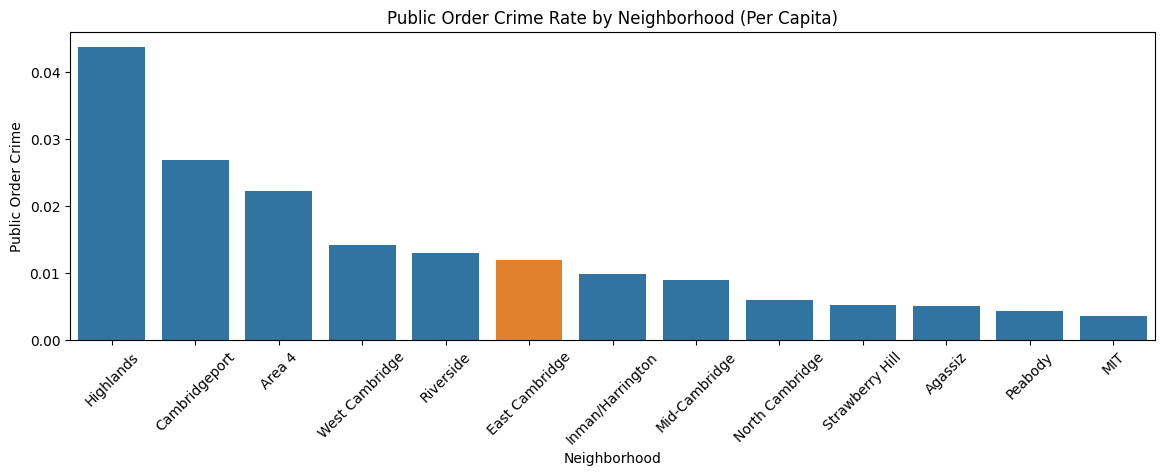

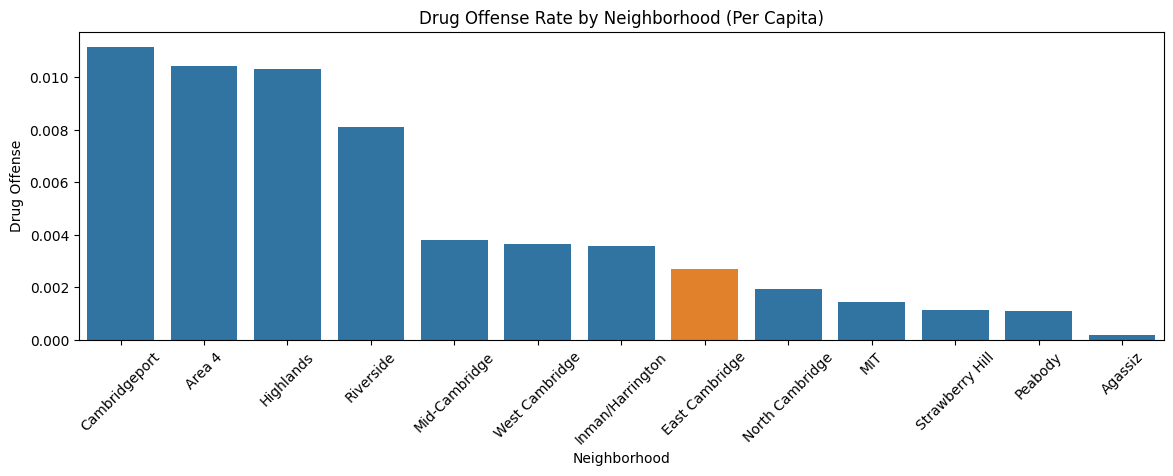

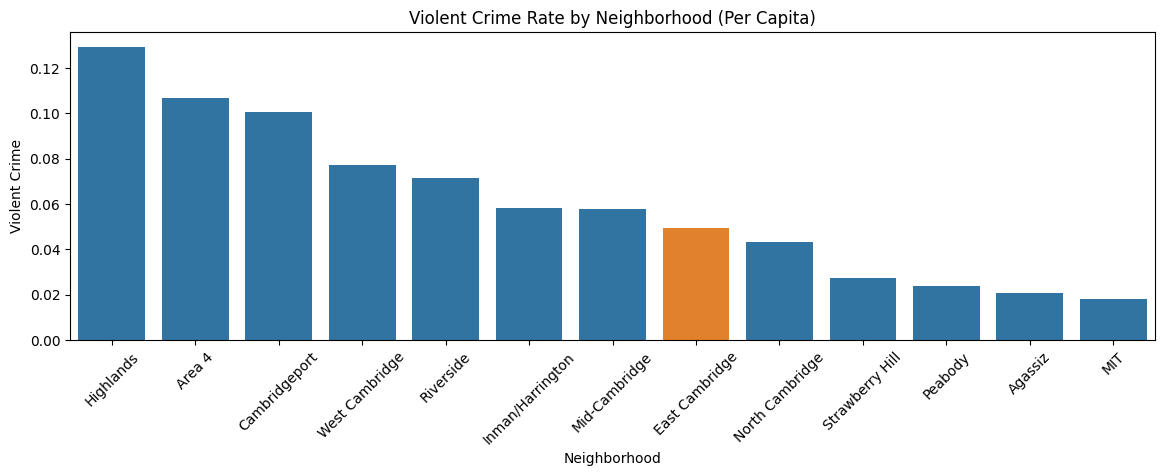

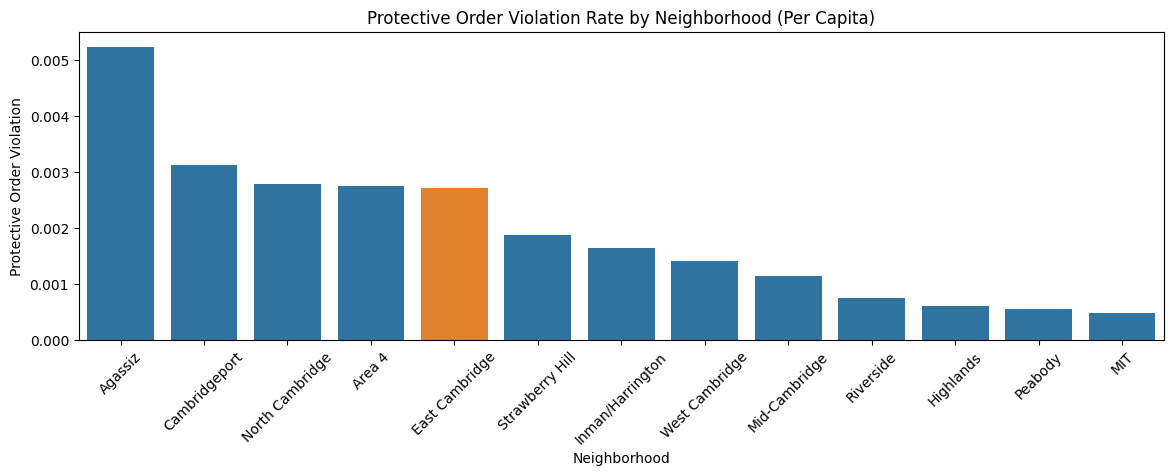

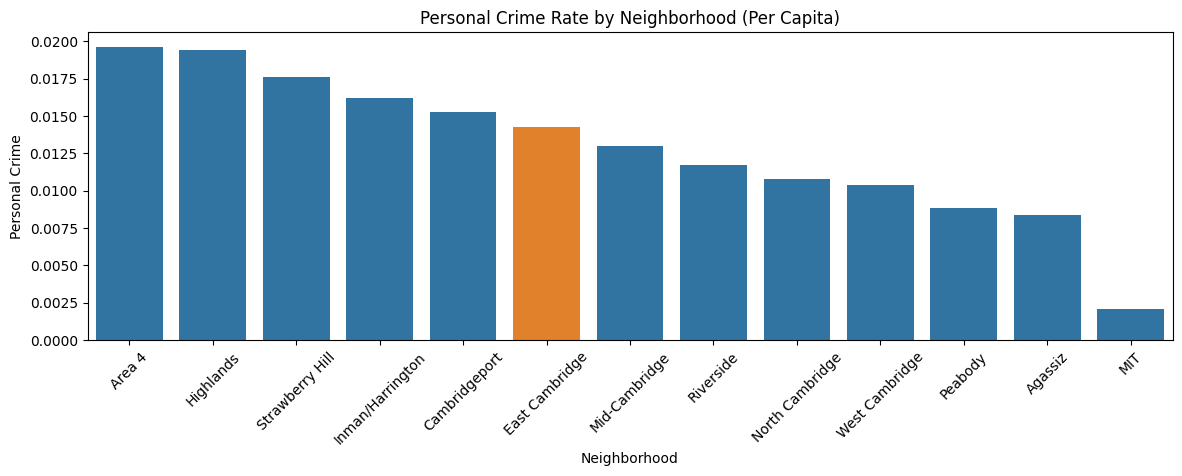

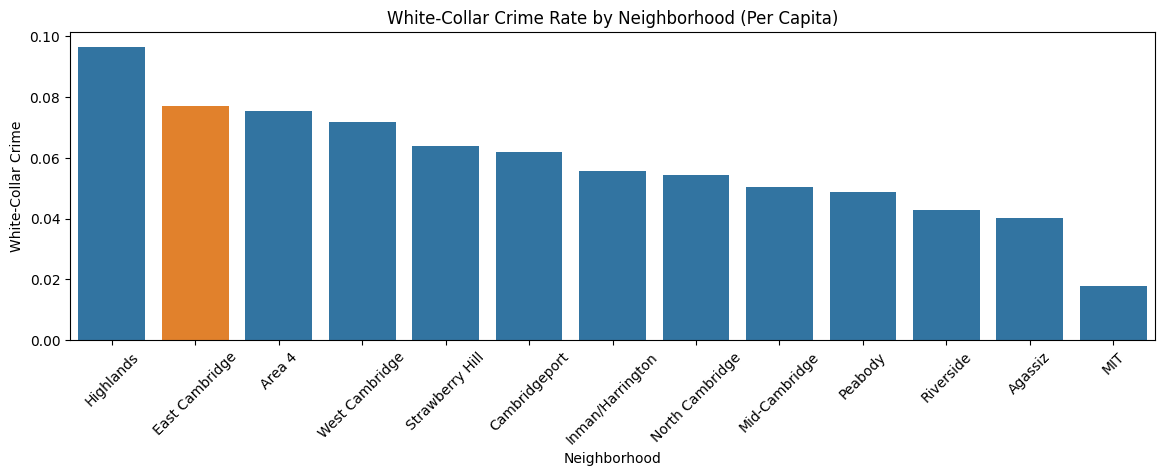

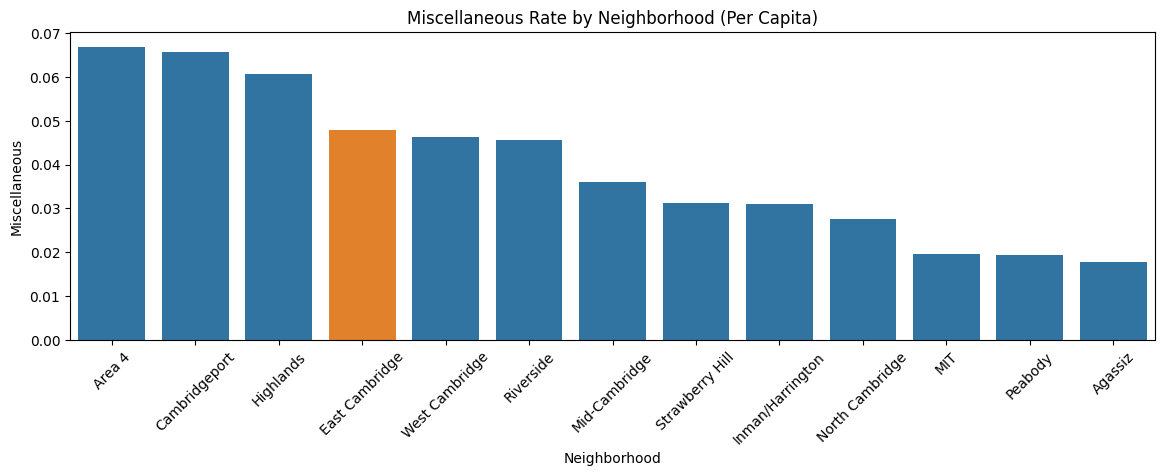

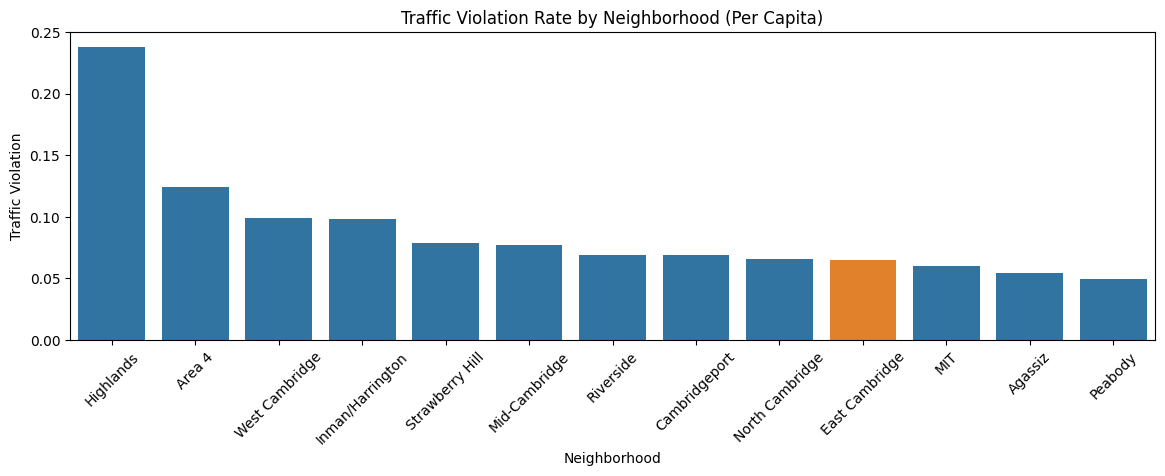

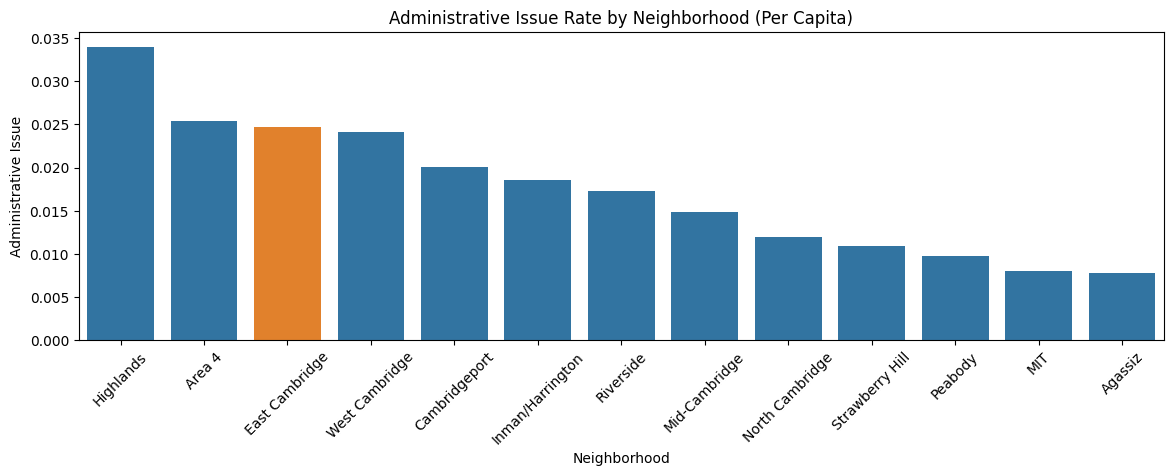

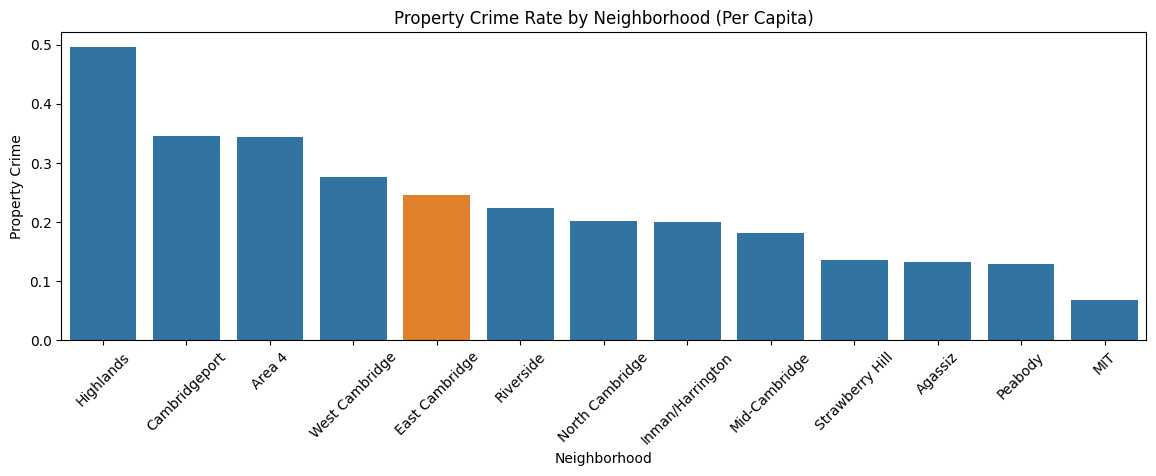

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

macro_crime_categories = set(crime_macro_categories.values())
colors = sns.color_palette('tab10', n_colors=2)
neighborhoods_colors = {neigh: colors[0] for neigh in rel_crime_table_macro.index}
neighborhoods_colors['East Cambridge'] = colors[1]

for category in macro_crime_categories:
    plt.figure(figsize=(14, 4))
    sorted_df = pd.DataFrame(rel_crime_table_macro[category].sort_values(ascending=False))
    sns.barplot(data=sorted_df, x='Neighborhood', hue='Neighborhood', y=category, palette=neighborhoods_colors)
    plt.title(f'{category} Rate by Neighborhood (Per Capita)')
    plt.xticks(rotation=45)
    plt.show()

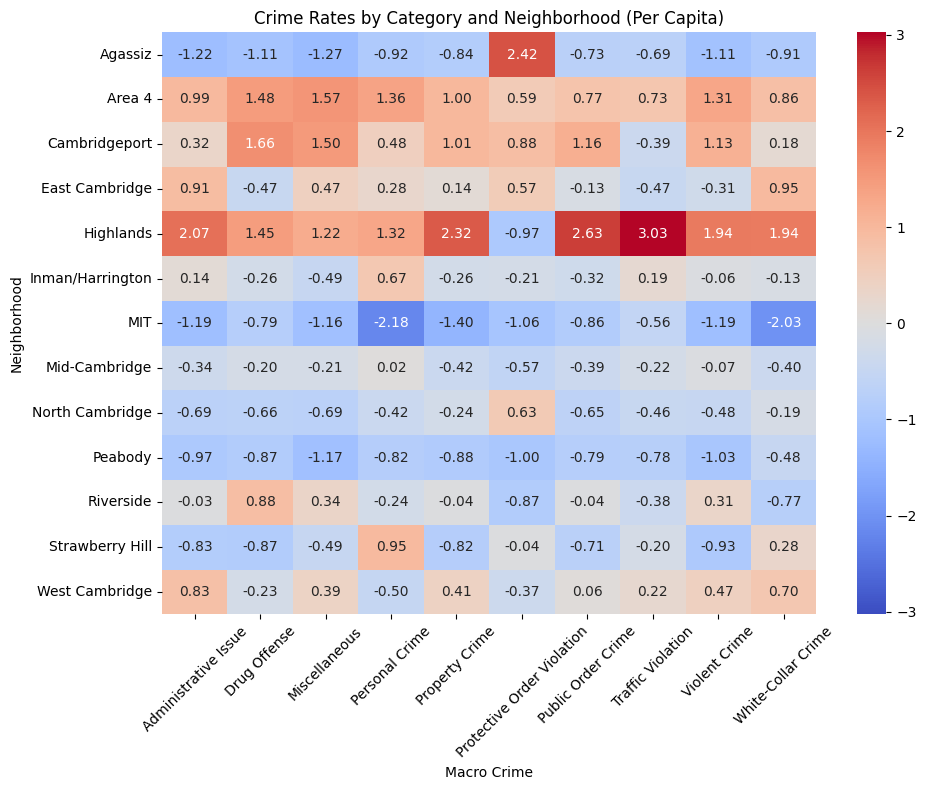

In [14]:
norm_crime_table_macro = (rel_crime_table_macro - rel_crime_table_macro.mean()) / rel_crime_table_macro.std()

vmin = -max(abs(norm_crime_table_macro.min().min()), abs(norm_crime_table_macro.max().max()))
vmax = -vmin

plt.figure(figsize=(10, 8))
sns.heatmap(data=norm_crime_table_macro, annot=True, fmt=".2f", cmap='coolwarm', vmin=vmin, vmax=vmax)
plt.title('Crime Rates by Category and Neighborhood (Per Capita)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [80]:
import geopandas as gpd
import folium
from IPython.display import display
import ipywidgets as widgets
from IPython.display import clear_output

# Load the shapefile using Geopandas
shapefile_path = 'C:\\Users\\nicco\\OneDrive\\Documents\\Github\\1. Pjts\\3. Cambridge Crime\\BOUNDARY_CDDNeighborhoods.shp'
geo_df = gpd.read_file(shapefile_path)

# Reproject to WGS84 (required for Folium maps)
if geo_df.crs != "EPSG:4326":
    geo_df = geo_df.to_crs(epsg=4326)

# Create a mapping dictionary to align neighborhood names
name_mapping = {
    "The Port": "Area 4",
    "Neighborhood Nine": "Peabody",
    "Wellington-Harrington": "Inman/Harrington",
    "Mid-Cambridge": "Mid-Cambridge",
    "North Cambridge": "North Cambridge",
    "Cambridge Highlands": "Highlands",
    "Strawberry Hill": "Strawberry Hill",
    "West Cambridge": "West Cambridge",
    "Riverside": "Riverside",
    "Cambridgeport": "Cambridgeport",
    "Area 2/MIT": "MIT",
    "East Cambridge": "East Cambridge",
    "Baldwin": "Agassiz",
}

# Map `geo_df['NAME']` to match `rel_crime_table_macro.index`
geo_df['Mapped_Name'] = geo_df['NAME'].map(name_mapping)

# Function to render the map based on selected macro crime
def render_map(selected_macro):
    clear_output(wait=True)  # Clear previous output to avoid duplicates

    # Create a DataFrame from the population dictionary
    pop_df = pd.DataFrame.from_dict(neighborhoods_pop_2020, orient='index', columns=['Population'])
    pop_df.index.name = 'Neighborhood'
    pop_df = pop_df.reset_index()

    # Merge the selected crime data and population into GeoDataFrame
    geo_df_selected = geo_df.merge(
        rel_crime_table_macro[[selected_macro]], how='left', left_on='Mapped_Name', right_index=True
    )
    geo_df_selected = geo_df_selected.merge(
        pop_df, how='left', left_on='Mapped_Name', right_on='Neighborhood'
    )
    geo_df_selected[selected_macro] = geo_df_selected[selected_macro].round(5)

    # Convert to GeoJSON
    geo_json = geo_df_selected.to_json()

    # Calculate the map's center
    center_coords = geo_df.geometry.centroid.y.mean(), geo_df.geometry.centroid.x.mean()

    # Create a Folium map
    m = folium.Map(location=center_coords, zoom_start=13.5)

    # Add the selected choropleth layer
    folium.Choropleth(
        geo_data=geo_json,
        data=geo_df_selected,
        columns=['Mapped_Name', selected_macro],
        key_on='feature.properties.Mapped_Name',
        fill_color='YlOrRd',
        fill_opacity=0.65,
        line_opacity=0.4,
        legend_name=f'Relative {selected_macro} Rate',
    ).add_to(m)

    # Add GeoJSON layer with click events
    style_function = lambda x: {'fillColor': 'transparent', 'color': 'transparent'}
    highlight_function = lambda x: {'fillColor': 'transparent', 'color': 'transparent'}
    
    folium.GeoJson(
        geo_json,
        style_function=style_function,
        highlight_function=highlight_function,
        tooltip=folium.GeoJsonTooltip(
            fields=['Mapped_Name', selected_macro, 'Population'],
            aliases=['Neighborhood:', f'{selected_macro} Score:', 'Population:'],
            style=("background-color: white; color: #333333; font-family: arial; font-size: 12px; padding: 10px;")
        )
    ).add_to(m)
    
    # Display the map
    display(crime_dropdown)  # Show dropdown again
    display(m)

In [81]:
# Dropdown menu for selecting crime category
crime_dropdown = widgets.Dropdown(
    options=rel_crime_table_macro.columns.tolist(),
    value='Violent Crime',  # Default selection
    description='Crime:',
)

# Link the dropdown to the render_map function
crime_dropdown.observe(lambda change: render_map(crime_dropdown.value), names='value')

# Initial rendering
render_map(crime_dropdown.value)

C:\Users\nicco\AppData\Local\Temp\ipykernel_108008\2829545516.py:57: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  center_coords = geo_df.geometry.centroid.y.mean(), geo_df.geometry.centroid.x.mean()


Dropdown(description='Crime:', index=6, options=('Administrative Issue', 'Drug Offense', 'Miscellaneous', 'PerÃ¢â‚¬Â¦

In [11]:
#### MAP WITH BOTH BOSTON AND CAMBRIDGE BUT SEPARATED


# import pandas as pd
# import numpy as np
# import geopandas as gpd
# import folium
# from IPython.display import display, clear_output
# import ipywidgets as widgets

# # Keep all your existing data loading and preprocessing code here, up until the widgets...

# # Create unified widgets
# municipality_dropdown = widgets.Dropdown(
#     options=['Cambridge', 'Boston'],
#     value='Cambridge',
#     description='City:',
#     style={'description_width': 'initial'}
# )

# crime_dropdown = widgets.Dropdown(
#     options=sorted(neighborhoods_crime_cambridge['Macro Crime'].unique()),
#     value='Violent Crime',
#     description='Crime:',
#     style={'description_width': 'initial'}
# )

# start_date_picker = widgets.DatePicker(
#     description='Start Date:',
#     value=pd.to_datetime('2015-01-01'),
#     style={'description_width': 'initial'}
# )

# end_date_picker = widgets.DatePicker(
#     description='End Date:',
#     value=pd.to_datetime('2025-01-07'),
#     style={'description_width': 'initial'}
# )

# controls = widgets.HBox([municipality_dropdown, crime_dropdown, start_date_picker, end_date_picker])

# def render_map(selected_municipality=None, selected_macro=None, start_date=None, end_date=None):
#     clear_output(wait=True)
    
#     if selected_municipality == 'Cambridge':
#         crime_data = neighborhoods_crime_cambridge
#         geo_df = geo_df_cambridge
#         pop_data = neighborhoods_pop_2020_cambridge
#         date_col = 'Date'
#         zoom_start = 13
#         pop_year = '2020'
#     else:  # Boston
#         crime_data = neighborhoods_crime_boston
#         geo_df = geo_df_boston
#         pop_data = neighborhoods_pop_2019_boston
#         date_col = 'Date'
#         zoom_start = 12
#         pop_year = '2019'
    
#     # Filter data by date
#     filtered_crime = crime_data[
#         (crime_data[date_col] >= pd.to_datetime(start_date)) & 
#         (crime_data[date_col] <= pd.to_datetime(end_date))
#     ].copy()
    
#     # Calculate crime rates
#     if selected_municipality == 'Cambridge':
#         crime_table_macro = filtered_crime.groupby(['Neighborhood', 'Macro Crime']).size().unstack('Macro Crime').fillna(0)
#         rel_crime_table_macro = crime_table_macro.div(pd.Series(pop_data), axis=0)
#     else:
#         crime_table_macro = filtered_crime.groupby(['Mapped_Neighborhood', 'Macro Crime']).size().unstack('Macro Crime').fillna(0)
#         rel_crime_table_macro = crime_table_macro.div(pd.Series(pop_data), axis=0)
    
#     # Create population DataFrame
#     pop_df = pd.DataFrame.from_dict(pop_data, orient='index', columns=['Population'])
#     pop_df.index.name = 'Neighborhood'
#     pop_df = pop_df.reset_index()

#     # Merge data
#     if selected_municipality == 'Cambridge':
#         geo_df_selected = geo_df.merge(
#             rel_crime_table_macro[[selected_macro]], how='left', left_on='Mapped_Name', right_index=True
#         )
#     else:
#         geo_df_selected = geo_df.merge(
#             rel_crime_table_macro[[selected_macro]], how='left', left_on='Mapped_Name', right_index=True
#         )
    
#     geo_df_selected = geo_df_selected.merge(
#         pop_df, how='left', left_on='Mapped_Name', right_on='Neighborhood'
#     )
#     geo_df_selected[selected_macro] = geo_df_selected[selected_macro].round(5)

#     # Create map
#     geo_json = geo_df_selected.to_json()
#     center_coords = geo_df.geometry.centroid.y.mean(), geo_df.geometry.centroid.x.mean()
#     m = folium.Map(location=center_coords, zoom_start=zoom_start)
    
#     # Add choropleth layer
#     folium.Choropleth(
#         geo_data=geo_json,
#         data=geo_df_selected,
#         columns=['Mapped_Name', selected_macro],
#         key_on='feature.properties.Mapped_Name',
#         fill_color='YlOrRd',
#         fill_opacity=0.65,
#         line_opacity=0.4,
#         legend_name=f'Relative {selected_macro} Rate',
#     ).add_to(m)

#     # Add tooltip layer
#     folium.GeoJson(
#         geo_json,
#         style_function=lambda x: {'fillColor': 'transparent', 'color': 'transparent'},
#         tooltip=folium.GeoJsonTooltip(
#             fields=['Mapped_Name', selected_macro, 'Population'],
#             aliases=['Neighborhood:', f'{selected_macro} Score:', f'Population ({pop_year}):'],
#             style=("background-color: white; color: #333333; font-family: arial; font-size: 12px; padding: 10px;")
#         )
#     ).add_to(m)
    
#     display(controls)
#     display(m)

# def update_crime_categories(*args):
#     if municipality_dropdown.value == 'Cambridge':
#         crime_dropdown.options = sorted(neighborhoods_crime_cambridge['Macro Crime'].unique())
#     else:
#         crime_dropdown.options = sorted(neighborhoods_crime_boston['Macro Crime'].unique())

# def update_map(change=None):
#     render_map(
#         selected_municipality=municipality_dropdown.value,
#         selected_macro=crime_dropdown.value,
#         start_date=start_date_picker.value,
#         end_date=end_date_picker.value
#     )

# # Link widgets to update functions
# municipality_dropdown.observe(lambda change: update_crime_categories(), names='value')
# municipality_dropdown.observe(lambda change: update_map(), names='value')
# crime_dropdown.observe(lambda change: update_map(), names='value')
# start_date_picker.observe(lambda change: update_map(), names='value')
# end_date_picker.observe(lambda change: update_map(), names='value')

# # Initial rendering
# update_map()

C:\Users\nicco\AppData\Local\Temp\ipykernel_32832\2403819799.py:93: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  center_coords = geo_df.geometry.centroid.y.mean(), geo_df.geometry.centroid.x.mean()
